<a href="https://colab.research.google.com/github/prometricas/Insectos_Gloria_Palma/blob/main/Clima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #1A56A0 0%, #2E86AB 100%);
            padding: 22px 28px; border-radius: 14px; margin-bottom: 4px;">
  <h1 style="color: white; margin: 0; font-size: 1.65em; letter-spacing: -0.5px;">
    🔬 Fase 1 — Carga, Depuración y Análisis Exploratorio
  </h1>
  <p style="color: #cde4f5; margin: 7px 0 0 0; font-size: 0.95em;">
    Proyecto: Predicción de patógenos en insectos vectores · Departamento del Tolima, Colombia · 2025
  </p>
</div>

---

## 1.1 Fuente y estructura de los datos

La base de datos oficial es la hoja **`TOLIMADETECCIONES`** del archivo `13-BASE_DE_DATOS_TOLIMA.xlsx`, la cual fue acordada con la investigadora como la versión canónica y depurada. Las columnas se organizan en tres grupos funcionales:

| Grupo | Variables | Descripción |
|---|---|---|
| **Identificación del sitio** | `DEPARTAMENTO`, `ZONA`, `MUNICIPIO`, `VEREDA` | Localización administrativa. Zona = Sur / Centro / Norte del Tolima |
| **Geoespacial y temporal** | `LATITUD (N)`, `LONGITUD (W)`, `M.S.N.M`, `FECHA COLECTA` | Coordenadas WGS-84, altitud en metros s.n.m., fecha de muestreo |
| **Descriptores del individuo** | `INDIVIDUO No.`, `SEXO`, `MORFOTIPO` | Código único, sexo (Macho/Hembra), morfotipo del vector (I, II, IV) |
| **Variables respuesta (targets)** | `DETECCIÓN ESPIROPLASMA`, `DETECCIÓN FITOPLASMA` | Variables binarias: 1 = positivo, 0 = negativo |

## 1.2 Advertencia metodológica crítica — Espiroplasma

<div style="background: #fff3cd; border-left: 5px solid #e6a817;
            padding: 14px 18px; border-radius: 6px; margin: 12px 0;">
<b>⚠️ DETECCIÓN ESPIROPLASMA — Modelado predictivo no viable</b><br><br>
De los 188 individuos muestreados, <b>solo 3 resultaron positivos para espiroplasma</b>
(prevalencia ≈ 1.6%). Con esta cantidad de casos positivos, cualquier clasificador
estadístico aprenderá trivialmente a predecir siempre "negativo" y alcanzará una
<i>accuracy</i> aparente del 98.4% sin haber aprendido nada relevante.<br><br>
La teoría estadística exige un mínimo de <b>10–20 eventos positivos por variable predictora</b>
considerada (regla EPV, <i>Events Per Variable</i>). Con solo 3 eventos positivos, este
mínimo no se cumple para ningún modelo con más de 1 variable.<br><br>
<b>Decisión metodológica:</b> para Espiroplasma se realizará únicamente análisis
descriptivo (localización de los 3 positivos, comparación de sus condiciones
frente al grupo negativo) y se incluirá una advertencia explícita en el informe final.
El modelado predictivo se aplicará exclusivamente a <b>Fitoplasma</b>.
</div>

## 1.3 Problema de pseudoreplicación

<div style="background: #e8f4f8; border-left: 5px solid #2E86AB;
            padding: 14px 18px; border-radius: 6px; margin: 12px 0;">
<b>🔁 Pseudoreplicación espacial</b><br><br>
Cada punto de colecta (vereda × fecha × coordenada) aportó entre 5 y 7 individuos.
Esto implica que todos los insectos de un mismo punto compartirán <b>idénticas variables
climáticas y de paisaje</b>. Un split aleatorio train/test ignoraría esta estructura
y produciría métricas de desempeño artificialmente infladas.<br><br>
<b>Solución implementada en Fase 4:</b> validación cruzada con
<code>GroupKFold(n_splits=5)</code>, usando el punto de colecta como grupo,
garantizando que ningún individuo de un sitio aparezca simultáneamente en
entrenamiento y prueba.
</div>

## 1.4 Código de esta celda

Esta celda ejecuta las siguientes operaciones:

1. **Carga** del archivo Excel (subida directa o desde Google Drive).
2. **Depuración** de cadenas con saltos de línea heredados del Excel original.
3. **Renombrado** de columnas para manejo programático más limpio.
4. **EDA visual** con 6 paneles: distribución por zona, morfotipo, sexo, prevalencia de fitoplasma por zona, altitud por zona y mapa de puntos de colecta.
5. **Construcción de `puntos_unicos`**: tabla con los 30 puntos geográfico-temporales únicos, usada como insumo en la Fase 2.

📂 Sube el archivo 13-BASE_DE_DATOS_TOLIMA.xlsx ...


Saving 13-BASE DE DATOS TOLIMA.xlsx to 13-BASE DE DATOS TOLIMA.xlsx
✅ Hoja cargada: 188 filas × 13 columnas
✅ Validación superada: sin nulos, coordenadas dentro del rango nacional

───────────────────────────────────────────────────────
  TARGET › Espiroplasma
  Positivos :    3  (  1.6%)
  Negativos :  185  ( 98.4%)
  Total     :  188
  ⚠️  DESBALANCE EXTREMO — modelado predictivo no recomendado

───────────────────────────────────────────────────────
  TARGET › Fitoplasma
  Positivos :  129  ( 68.6%)
  Negativos :   59  ( 31.4%)
  Total     :  188


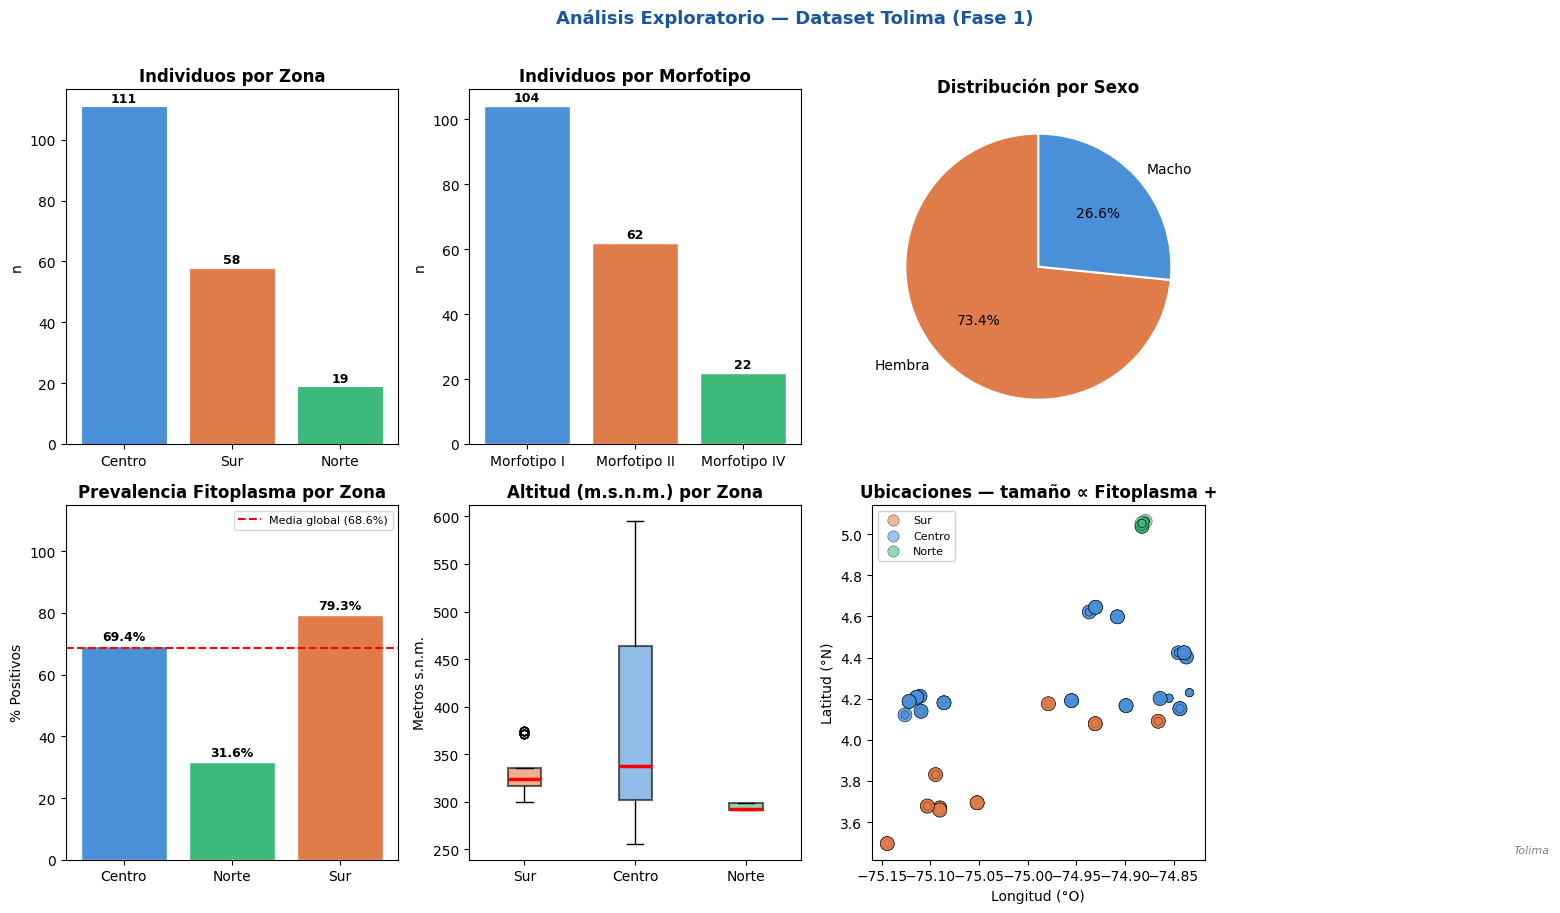

✅ Figura guardada: fase1_eda_tolima.png

📍 Puntos únicos de colecta identificados: 30
   (cada punto = 1 llamada a la API climática en Fase 2)



,ZONA,MUNICIPIO,FECHA COLECTA,LAT,LON,ALTITUD_M,n_indiv,pct_fito,n_espiro
0,Centro,Alvarado,2025-07-02,4.598230,-74.907720,338,6,100.0,1
1,Centro,Alvarado,2025-07-02,4.622070,-74.936650,344,5,60.0,0
2,Centro,Alvarado,2025-07-02,4.644970,-74.930130,377,7,85.7,0
3,Centro,Coello,2025-06-30,4.402930,-74.836850,256,6,66.7,0
4,Centro,Coello,2025-06-30,4.423190,-74.845100,271,7,42.9,0
5,Centro,Coello,2025-06-30,4.424010,-74.839080,267,7,71.4,0
6,Centro,Espinal,2025-06-13,4.151690,-74.843430,302,7,85.7,0
7,Centro,Espinal,2025-06-13,4.166280,-74.898830,327,6,100.0,0
8,Centro,Espinal,2025-06-13,4.190460,-74.954870,365,6,100.0,0
9,Centro,Flandes,2025-06-24,4.201080,-74.863820,314,6,66.7,0



════════════════════════════════════════════════════════════
  ANÁLISIS DESCRIPTIVO — ESPIROPLASMA (3 positivos)
  (Modelado predictivo descartado por insuficiencia de casos)
════════════════════════════════════════════════════════════


,ZONA,MUNICIPIO,VEREDA,FECHA COLECTA,LAT,LON,ALTITUD_M,SEXO,MORFOTIPO,FITOPLASMA
0,Sur,Coyaima,Castilla,2025-06-25,3.83066,-75.09468,324,Macho,Morfotipo II,1
1,Sur,Guamo,Serrezuela,2025-06-19,4.07825,-74.93053,317,Hembra,Morfotipo I,0
2,Centro,Alvarado,Rincón de Chipalo,2025-07-02,4.59823,-74.90772,338,Macho,Morfotipo II,1


  Positivos: altitud media = 326 m, zonas = {'Sur': 2, 'Centro': 1}
  Negativos: altitud media = 358 m, zonas = {'Centro': 110, 'Sur': 56, 'Norte': 19}

✅ Fase 1 completada. Variable 'puntos_unicos' lista para Fase 2.


In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# FASE 1 — Carga, Depuración y Análisis Exploratorio
# ══════════════════════════════════════════════════════════════════════════════

# ── Librerías ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Paleta de colores por zona (consistente en todo el cuaderno)
PALETA_ZONA  = {'Sur': '#e07b4a', 'Centro': '#4a90d9', 'Norte': '#3dba7a'}
AZUL_BASE    = '#1A56A0'
COLOR_POS    = '#d64242'
COLOR_NEG    = '#aec6e8'

# ── Carga del archivo ─────────────────────────────────────────────────────────
# Opción A — subida directa al entorno de Colab (descomentar la que corresponda)
from google.colab import files as colab_files
print("📂 Sube el archivo 13-BASE_DE_DATOS_TOLIMA.xlsx ...")
subido = colab_files.upload()
RUTA_EXCEL = list(subido.keys())[0]

# Opción B — desde Google Drive (descomentar si el archivo ya está en Drive)
# from google.colab import drive
# drive.mount('/content/drive')
# RUTA_EXCEL = '/content/drive/MyDrive/TU_CARPETA/13-BASE_DE_DATOS_TOLIMA.xlsx'

# Cargo únicamente la hoja oficial acordada con la investigadora
df = pd.read_excel(RUTA_EXCEL, sheet_name='TOLIMADETECCIONES')
print(f"✅ Hoja cargada: {df.shape[0]} filas × {df.shape[1]} columnas")

# ── Depuración de cadenas ─────────────────────────────────────────────────────
# Varios campos heredan saltos de línea del Excel original; los elimino
for col in ['VEREDA', 'MUNICIPIO', 'ZONA', 'SEXO', 'MORFOTIPO']:
    df[col] = df[col].str.replace(r'\n', ' ', regex=True).str.strip()

df['FECHA COLECTA'] = pd.to_datetime(df['FECHA COLECTA'])

# Renombro columnas problemáticas para el manejo programático
df.rename(columns={
    'LATITUD (N)'          : 'LAT',
    'LONGITUD (W)'         : 'LON',
    'M.S.N.M'             : 'ALTITUD_M',
    'INDIVIDUO No.'        : 'INDIVIDUO',
    'DETECCIÓN ESPIROPLASMA': 'ESPIROPLASMA',
    'DETECCIÓN FITOPLASMA' : 'FITOPLASMA'
}, inplace=True)

# ── Validación básica ─────────────────────────────────────────────────────────
assert df.isnull().sum().sum() == 0, "⚠️ Hay valores nulos — revisar antes de continuar"
assert df['LAT'].between(-5, 10).all(), "⚠️ Latitudes fuera del rango esperado para Colombia"
assert df['LON'].between(-80, -65).all(), "⚠️ Longitudes fuera del rango esperado para Colombia"
print("✅ Validación superada: sin nulos, coordenadas dentro del rango nacional")

# ── Reporte de targets ────────────────────────────────────────────────────────
def reporte_target(serie, nombre):
    n     = len(serie)
    pos   = int(serie.sum())
    neg   = n - pos
    pct   = 100 * pos / n
    print(f"\n{'─'*55}")
    print(f"  TARGET › {nombre}")
    print(f"  Positivos : {pos:4d}  ({pct:5.1f}%)")
    print(f"  Negativos : {neg:4d}  ({100-pct:5.1f}%)")
    print(f"  Total     : {n:4d}")
    if pct < 5:
        print("  ⚠️  DESBALANCE EXTREMO — modelado predictivo no recomendado")
    elif pct < 20 or pct > 80:
        print("  ⚡ Desbalance moderado — usar class_weight y métricas apropiadas")

reporte_target(df['ESPIROPLASMA'], 'Espiroplasma')
reporte_target(df['FITOPLASMA'],   'Fitoplasma')

# ── EDA visual ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Análisis Exploratorio — Dataset Tolima (Fase 1)',
             fontsize=13, fontweight='bold', color=AZUL_BASE, y=1.01)

# Panel 1: individuos por zona
zona_c = df['ZONA'].value_counts()
bars1  = axes[0, 0].bar(zona_c.index, zona_c.values,
                         color=[PALETA_ZONA[z] for z in zona_c.index],
                         edgecolor='white', linewidth=0.8)
axes[0, 0].set_title('Individuos por Zona', fontweight='bold')
axes[0, 0].set_ylabel('n')
for bar, val in zip(bars1, zona_c.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, val + 1.5,
                    str(val), ha='center', fontsize=9, fontweight='bold')

# Panel 2: individuos por morfotipo
morf_c   = df['MORFOTIPO'].value_counts()
colores2 = ['#4a90d9', '#e07b4a', '#3dba7a', '#9b59b6']
bars2    = axes[0, 1].bar(morf_c.index, morf_c.values,
                          color=colores2[:len(morf_c)], edgecolor='white')
axes[0, 1].set_title('Individuos por Morfotipo', fontweight='bold')
axes[0, 1].set_ylabel('n')
for bar, val in zip(bars2, morf_c.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, val + 1.5,
                    str(val), ha='center', fontsize=9, fontweight='bold')

# Panel 3: distribución de sexo
sexo_c = df['SEXO'].value_counts()
axes[0, 2].pie(sexo_c, labels=sexo_c.index, autopct='%1.1f%%',
               colors=['#e07b4a', '#4a90d9'], startangle=90,
               wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0, 2].set_title('Distribución por Sexo', fontweight='bold')

# Panel 4: prevalencia de fitoplasma por zona
prev_zona = (df.groupby('ZONA')['FITOPLASMA']
               .agg(positivos='sum', total='count')
               .assign(pct=lambda x: 100 * x['positivos'] / x['total'])
               .reset_index())
bars4 = axes[1, 0].bar(prev_zona['ZONA'], prev_zona['pct'],
                        color=[PALETA_ZONA[z] for z in prev_zona['ZONA']],
                        edgecolor='white')
axes[1, 0].axhline(100 * df['FITOPLASMA'].mean(), color='red',
                   ls='--', lw=1.5, label=f"Media global ({100*df['FITOPLASMA'].mean():.1f}%)")
axes[1, 0].set_title('Prevalencia Fitoplasma por Zona', fontweight='bold')
axes[1, 0].set_ylabel('% Positivos')
axes[1, 0].set_ylim(0, 115)
axes[1, 0].legend(fontsize=8)
for bar, pct in zip(bars4, prev_zona['pct']):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, pct + 2,
                    f'{pct:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Panel 5: altitud por zona (boxplot)
datos_box = [df[df['ZONA'] == z]['ALTITUD_M'].values for z in ['Sur', 'Centro', 'Norte']]
bp = axes[1, 1].boxplot(datos_box, labels=['Sur', 'Centro', 'Norte'],
                         medianprops=dict(color='red', lw=2.5),
                         boxprops=dict(lw=1.5),
                         patch_artist=True)
for patch, zona in zip(bp['boxes'], ['Sur', 'Centro', 'Norte']):
    patch.set_facecolor(PALETA_ZONA[zona])
    patch.set_alpha(0.6)
axes[1, 1].set_title('Altitud (m.s.n.m.) por Zona', fontweight='bold')
axes[1, 1].set_ylabel('Metros s.n.m.')

# Panel 6: mapa de ubicación de muestreos
for zona, color in PALETA_ZONA.items():
    sub = df[df['ZONA'] == zona]
    axes[1, 2].scatter(sub['LON'], sub['LAT'],
                       c=color, s=sub['FITOPLASMA'].map({0: 35, 1: 100}),
                       alpha=0.55, edgecolors='k', linewidths=0.4, label=zona)
axes[1, 2].set_title('Ubicaciones — tamaño ∝ Fitoplasma +', fontweight='bold')
axes[1, 2].set_xlabel('Longitud (°O)')
axes[1, 2].set_ylabel('Latitud (°N)')
axes[1, 2].legend(fontsize=8, framealpha=0.9)
# Anotación de la región Tolima para contexto
axes[1, 2].text(-74.5, 3.45, 'Tolima', fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.show()

# ── Tabla de puntos únicos de colecta ─────────────────────────────────────────
# Esta tabla es el insumo principal de la Fase 2; cada fila = una llamada a la API
puntos_unicos = (
    df.groupby(['ZONA', 'MUNICIPIO', 'FECHA COLECTA', 'LAT', 'LON', 'ALTITUD_M'])
      .agg(
          n_indiv       = ('INDIVIDUO',    'count'),
          n_fitoplasma  = ('FITOPLASMA',   'sum'),
          n_espiro      = ('ESPIROPLASMA', 'sum'),
      )
      .reset_index()
)
puntos_unicos['pct_fito'] = (100 * puntos_unicos['n_fitoplasma'] / puntos_unicos['n_indiv']).round(1)

print(f"\n📍 Puntos únicos de colecta identificados: {len(puntos_unicos)}")
print(f"   (cada punto = 1 llamada a la API climática en Fase 2)\n")
display(puntos_unicos[['ZONA','MUNICIPIO','FECHA COLECTA','LAT','LON',
                        'ALTITUD_M','n_indiv','pct_fito','n_espiro']]
        .sort_values(['ZONA','MUNICIPIO'])
        .reset_index(drop=True))

# ── Análisis descriptivo de los 3 positivos de espiroplasma ──────────────────
print("\n" + "═"*60)
print("  ANÁLISIS DESCRIPTIVO — ESPIROPLASMA (3 positivos)")
print("  (Modelado predictivo descartado por insuficiencia de casos)")
print("═"*60)
positivos_espiro = df[df['ESPIROPLASMA'] == 1][
    ['ZONA','MUNICIPIO','VEREDA','FECHA COLECTA','LAT','LON','ALTITUD_M','SEXO','MORFOTIPO','FITOPLASMA']
]
display(positivos_espiro.reset_index(drop=True))

# Comparación de altitud media entre positivos y negativos
for grupo, label in [(1, 'Positivos'), (0, 'Negativos')]:
    sub = df[df['ESPIROPLASMA'] == grupo]
    print(f"  {label}: altitud media = {sub['ALTITUD_M'].mean():.0f} m, "
          f"zonas = {sub['ZONA'].value_counts().to_dict()}")

print("\n✅ Fase 1 completada. Variable 'puntos_unicos' lista para Fase 2.")

<div style="background: linear-gradient(135deg, #1a7a4a 0%, #2db870 100%);
            padding: 22px 28px; border-radius: 14px; margin-bottom: 4px;">
  <h1 style="color: white; margin: 0; font-size: 1.65em; letter-spacing: -0.5px;">
    🌦️ Fase 2 — Enriquecimiento Climático y ENSO
  </h1>
  <p style="color: #c8f0da; margin: 7px 0 0 0; font-size: 0.95em;">
    API: Open-Meteo ERA5-Land (gratuita, sin clave) · 30 puntos × 4 ventanas temporales = 80 variables nuevas
  </p>
</div>

---

## 2.1 ¿Por qué no basta con el día de colecta?

Los insectos vectores no adquieren ni transmiten patógenos en un instante puntual. Su estado fisiológico, densidad poblacional y comportamiento responden al **contexto climático acumulado** durante el desarrollo del cultivo hospedero. Según la investigadora, los cultivos muestreados tenían aproximadamente **100 días de establecidos** al momento de la colecta; esto significa que toda la historia climática desde la siembra puede ser ecológicamente relevante.

Descargar solo las condiciones del día exacto de muestreo capturaría un "snapshot" sin contexto, perdiendo señales fundamentales como:

- Acumulación de lluvias que favorece la explosión poblacional del insecto
- Períodos de sequía que concentran poblaciones en parches de cultivo
- Ondas de calor que estresan la planta y la hacen más susceptible
- El coletazo de **La Niña 2024–2025**, activa aproximadamente entre enero y mayo de 2025

## 2.2 Diseño de ventanas temporales

Para cada punto de colecta se calculan estadísticos agregados en **cuatro ventanas retrospectivas**, todas terminando el día anterior a la colecta:

| Ventana | Duración | Interpretación ecológica |
|---|---|---|
| **7 días** | 1 semana | Efecto agudo inmediato — respuesta comportamental rápida del insecto |
| **30 días** | 1 mes | Ciclo de vida completo de la mayoría de las ninfas |
| **90 días** | 1 trimestre | Dinámica poblacional estacional; período solicitado por la investigadora |
| **120 días** | 4 meses | Ciclo completo del cultivo desde la siembra hasta la colecta |

## 2.3 Variables calculadas por ventana

Para cada una de las 4 ventanas se generan **19 estadísticos**, resultando en 76 variables climáticas + 4 variables ENSO = **80 variables nuevas** en total:

| Grupo | Variables generadas |
|---|---|
| **Temperatura** | Media, máxima media, mínima media, rango diario medio, días con T > 30 °C |
| **Precipitación** | Total acumulada, media diaria, días con lluvia (≥ 1 mm), racha máxima seca, máximo diario |
| **Balance hídrico** | ET₀ total, déficit hídrico, índice de aridez |
| **Fisiología del insecto** | Grados-día acumulados (GDD) |
| **Energía y atmósfera** | Radiación solar media, humedad relativa media y mínima, velocidad media del viento, horas de sol |

### Ecuaciones implementadas

**Grados-día acumulados** — cuantifican el desarrollo termal del insecto en la ventana de $N$ días:

$$GDD_{ventana} = \sum_{d=1}^{N} \max\!\left(T_{\text{media},d} - T_{\text{base}}, \; 0\right)$$

donde $T_{\text{base}} = 10\,°C$ (temperatura umbral estándar para insectos fitófagos).

**Déficit hídrico** — diferencia entre demanda evaporativa y oferta de agua:

$$D = ET_0^{total} - P_{total}$$

Un valor positivo indica estrés hídrico en el cultivo; negativo indica exceso de humedad.

**Índice de aridez de Budyko** (versión simplificada):

$$I_a = \frac{P_{total}}{ET_0^{total}}$$

Valores $I_a < 0.5$ = árido; $0.5$–$1.0$ = semiárido; $> 1.0$ = húmedo.

## 2.4 Fuente climática: Open-Meteo ERA5-Land

Se utiliza la API de archivo histórico de **Open-Meteo** (<https://archive-api.open-meteo.com>), que distribuye libremente datos del reanálisis **ERA5-Land** del Centro Europeo de Pronóstico a Mediano Plazo (ECMWF).

- **Resolución espacial:** ~9 km (0.1°)
- **Resolución temporal:** datos diarios (temperatura, precipitación, ET₀, radiación, viento) y horarios (humedad relativa, agregada a media diaria)
- **Período disponible:** desde 1940 hasta la actualidad
- **Sin registro ni API key:** solo se requiere la librería `requests`

## 2.5 Fenómeno ENSO — Índice ONI

El **Oceanic Niño Index (ONI)** es el índice oficial de NOAA para clasificar las fases ENSO:

| Condición | Umbral ONI |
|---|---|
| 🔵 **La Niña** | ONI ≤ −0.5 °C |
| ⚪ **Neutro** | −0.5 °C < ONI < +0.5 °C |
| 🔴 **El Niño** | ONI ≥ +0.5 °C |

Se descarga automáticamente del portal CPC-NOAA. Si la descarga falla, se usan los valores reportados oficialmente para 2024–2025, donde La Niña estuvo activa de septiembre 2024 a abril 2025 con un ONI mínimo de aproximadamente −1.0 °C en noviembre–diciembre 2024.

Se asignan **dos valores ONI** por individuo: el del mes de colecta y el del trimestre previo, capturando tanto el estado ENSO en el momento del muestreo como su antecedente climático.

## 2.6 Salida de esta fase

Al finalizar esta celda se dispone de:

- **`df_master`**: DataFrame de 188 filas × ~93 columnas (variables originales + 80 climáticas)
- **`fase2_base_maestra.csv`**: exportación de `df_master` para respaldo y uso en herramientas externas
- **`fase2_correlacion_clima_fito.png`**: gráfica de correlaciones Pearson entre variables climáticas (ventana 90d) y la detección de Fitoplasma

✅ ONI descargado desde NOAA: 914 registros

🌎 Iniciando descarga climática para 30 puntos de colecta ...
   Ventanas: ['7d', '30d', '90d', '120d'] | Estadísticos por ventana: 19
   Variables nuevas esperadas: 80 (climáticas + ENSO)

  [01/30] Alvarado              (4.5982, -74.9077)  2025-07-02 ... ✅
  [02/30] Alvarado              (4.6221, -74.9367)  2025-07-02 ... ✅
  [03/30] Alvarado              (4.6450, -74.9301)  2025-07-02 ... ✅
  [04/30] Coello                (4.4029, -74.8368)  2025-06-30 ... ✅
  [05/30] Coello                (4.4232, -74.8451)  2025-06-30 ... ✅
  [06/30] Coello                (4.4240, -74.8391)  2025-06-30 ... ✅
  [07/30] Espinal               (4.1517, -74.8434)  2025-06-13 ... ✅
  [08/30] Espinal               (4.1663, -74.8988)  2025-06-13 ... ✅
  [09/30] Espinal               (4.1905, -74.9549)  2025-06-13 ... ✅
  [10/30] Flandes               (4.2011, -74.8638)  2025-06-24 ... ✅
  [11/30] Flandes               (4.2025, -74.8547)  2025-06-24 ... ✅
  [12/30

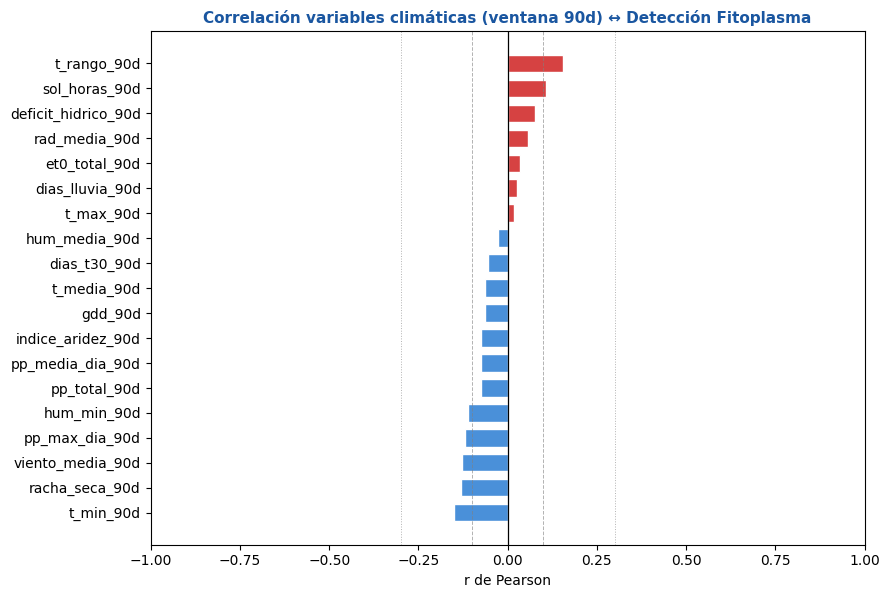

✅ Figura guardada: fase2_correlacion_clima_fito.png
✅ Base maestra exportada: 'fase2_base_maestra.csv'

📋 Inventario de variables — base maestra:
  Descriptores del individuo    :   6 variables
  Geoespacial y temporal        :   3 variables
  Clima — 7 días                :  19 variables
  Clima — 30 días               :  19 variables
  Clima — 90 días               :  19 variables
  Clima — 120 días              :  19 variables
  ENSO / ONI                    :   4 variables
  Targets                       :   2 variables
  ────────────────────────────────────────
  TOTAL                         :  91 variables

✅ Fase 2 completada. 'df_master' listo para Fase 3 (paisaje y vegetación).


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# FASE 2 — Enriquecimiento Climático y ENSO
# ══════════════════════════════════════════════════════════════════════════════

# ── Librerías adicionales ─────────────────────────────────────────────────────
import requests
import time
from datetime import timedelta
from io import StringIO

# ── Parámetros globales de la descarga ───────────────────────────────────────
VENTANAS_DIAS = {'7d': 7, '30d': 30, '90d': 90, '120d': 120}
T_BASE_GDD    = 10.0   # °C — temperatura umbral para grados-día del insecto

VARS_DAILY = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'precipitation_sum', 'rain_sum', 'precipitation_hours',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration',
    'windspeed_10m_max', 'windspeed_10m_mean', 'sunshine_duration'
]
VARS_HOURLY = ['relative_humidity_2m']

# ── Funciones de descarga y transformación ────────────────────────────────────

def descargar_openmeteo(lat, lon, fecha_ini, fecha_fin, reintentos=3):
    """Descargo datos ERA5-Land de Open-Meteo para un punto y período dado."""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        'latitude':   round(lat, 5),
        'longitude':  round(lon, 5),
        'start_date': fecha_ini.strftime('%Y-%m-%d'),
        'end_date':   fecha_fin.strftime('%Y-%m-%d'),
        'daily':      ','.join(VARS_DAILY),
        'hourly':     ','.join(VARS_HOURLY),
        'timezone':   'America/Bogota'
    }
    for intento in range(reintentos):
        try:
            resp = requests.get(url, params=params, timeout=40)
            resp.raise_for_status()
            return resp.json()
        except requests.RequestException as exc:
            if intento < reintentos - 1:
                time.sleep(2 ** intento)   # retroceso exponencial entre reintentos
            else:
                raise RuntimeError(f"Descarga fallida tras {reintentos} intentos: {exc}")


def json_a_series_diarias(data_json):
    """Convierto la respuesta JSON de Open-Meteo en un DataFrame diario con humedad agregada."""
    df_d = pd.DataFrame(data_json['daily'])
    df_d['time'] = pd.to_datetime(df_d['time'])
    df_d.rename(columns={'time': 'fecha'}, inplace=True)

    # Agrego la humedad relativa horaria a media diaria y la uno al DataFrame diario
    df_h = pd.DataFrame(data_json['hourly'])
    df_h['time']  = pd.to_datetime(df_h['time'])
    df_h['fecha'] = df_h['time'].dt.normalize()
    hum_diaria = (df_h.groupby('fecha')['relative_humidity_2m']
                      .mean()
                      .reset_index()
                      .rename(columns={'relative_humidity_2m': 'humedad_rel_media'}))

    return df_d.merge(hum_diaria, on='fecha', how='left')


def agregar_ventana(df_clima, fecha_colecta, n_dias):
    """
    Calculo estadísticos resumidos para la ventana de n_dias días previos
    (sin incluir el día de colecta, que aún no refleja el clima acumulado).
    """
    fecha_fin = fecha_colecta - timedelta(days=1)
    fecha_ini = fecha_colecta - timedelta(days=n_dias)
    sub = df_clima.loc[
        (df_clima['fecha'] >= fecha_ini) & (df_clima['fecha'] <= fecha_fin)
    ].copy()

    if len(sub) == 0:
        return {}

    tm  = sub['temperature_2m_mean'].dropna()
    tx  = sub['temperature_2m_max'].dropna()
    tn  = sub['temperature_2m_min'].dropna()
    pp  = sub['precipitation_sum'].fillna(0)
    et0 = sub['et0_fao_evapotranspiration'].fillna(0)
    rad = sub['shortwave_radiation_sum'].fillna(0)
    hum = sub['humedad_rel_media'].dropna()
    ws  = sub['windspeed_10m_mean'].dropna()
    sun = sub['sunshine_duration'].fillna(0)   # segundos/día

    # Grados-día acumulados: suma de max(T_media - T_base, 0) para cada día
    gdd_acum = float((tm - T_BASE_GDD).clip(lower=0).sum())

    # Racha máxima de días secos consecutivos (pp < 1 mm)
    dias_secos     = (pp < 1.0).astype(int).values
    racha_max      = 0
    racha_actual   = 0
    for s in dias_secos:
        racha_actual = (racha_actual + 1) * s   # reinicia en 0 si s == 0
        racha_max    = max(racha_max, racha_actual)

    # Índice de aridez (razón oferta/demanda hídrica)
    et0_total = float(et0.sum())
    pp_total  = float(pp.sum())
    i_aridez  = pp_total / et0_total if et0_total > 0 else np.nan

    d = n_dias  # sufijo para nombres de columnas
    return {
        f't_media_{d}d'       : float(tm.mean())                    if len(tm) else np.nan,
        f't_max_{d}d'         : float(tx.mean())                    if len(tx) else np.nan,
        f't_min_{d}d'         : float(tn.mean())                    if len(tn) else np.nan,
        f't_rango_{d}d'       : float((tx.values - tn.values).mean()) if len(tx) == len(tn) and len(tx) > 0 else np.nan,
        f'dias_t30_{d}d'      : int((tx > 30).sum())               if len(tx) else 0,
        f'pp_total_{d}d'      : pp_total,
        f'pp_media_dia_{d}d'  : float(pp.mean()),
        f'dias_lluvia_{d}d'   : int((pp >= 1.0).sum()),
        f'racha_seca_{d}d'    : racha_max,
        f'pp_max_dia_{d}d'    : float(pp.max()),
        f'et0_total_{d}d'     : et0_total,
        f'deficit_hidrico_{d}d': et0_total - pp_total,
        f'indice_aridez_{d}d' : i_aridez,
        f'gdd_{d}d'           : gdd_acum,
        f'rad_media_{d}d'     : float(rad.mean()),
        f'hum_media_{d}d'     : float(hum.mean())                   if len(hum) else np.nan,
        f'hum_min_{d}d'       : float(hum.min())                    if len(hum) else np.nan,
        f'viento_media_{d}d'  : float(ws.mean())                    if len(ws) else np.nan,
        f'sol_horas_{d}d'     : float(sun.sum()) / 3600.0,          # segundos → horas
    }


# ── Descarga del índice ONI desde NOAA ───────────────────────────────────────

def descargar_oni():
    """Descargo el Oceanic Niño Index (ONI) mensual del portal CPC-NOAA."""
    url = "https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt"
    try:
        resp = requests.get(url, timeout=25)
        resp.raise_for_status()
        oni  = pd.read_csv(StringIO(resp.text), sep=r'\s+', engine='python')
        # El archivo contiene: SEAS  YR  TOTAL  CLIM  ANOM
        oni.rename(columns={'YR': 'anio', 'ANOM': 'oni_anom'}, inplace=True)

        # Mapeo cada temporada de 3 meses al mes central para alinear con fechas de colecta
        mes_central = {
            'DJF': 1, 'JFM': 2, 'FMA': 3, 'MAM': 4, 'AMJ': 5, 'MJJ': 6,
            'JJA': 7, 'JAS': 8, 'ASO': 9, 'SON': 10, 'OND': 11, 'NDJ': 12
        }
        oni['mes'] = oni['SEAS'].map(mes_central)
        oni.dropna(subset=['mes'], inplace=True)
        oni['mes'] = oni['mes'].astype(int)
        print(f"✅ ONI descargado desde NOAA: {len(oni)} registros")
        return oni[['anio', 'mes', 'oni_anom']]

    except Exception as exc:
        print(f"⚠️  No se pudo conectar a NOAA ({exc}).")
        print("   Uso tabla manual con valores reportados oficialmente (2024–2025).")
        # Valores ONI oficiales para el período relevante del estudio
        datos_manuales = {
            'anio': [2024]*6 + [2025]*7,
            'mes' : [7, 8, 9, 10, 11, 12,  1, 2, 3, 4, 5, 6, 7],
            # Fuente: NOAA/CPC Oceanic Niño Index, consultado abril 2025
            'oni_anom': [-0.2, -0.3, -0.6, -0.9, -1.0, -0.9,
                         -0.9, -0.8, -0.7, -0.5, -0.2,  0.1,  0.2]
        }
        return pd.DataFrame(datos_manuales)


def asignar_oni(fecha, oni_df):
    """Busco el valor ONI y la fase ENSO para el mes y año de una fecha dada."""
    fila = oni_df[(oni_df['anio'] == fecha.year) & (oni_df['mes'] == fecha.month)]
    if not fila.empty:
        val = float(fila.iloc[0]['oni_anom'])
    else:
        val = np.nan

    if np.isnan(val):
        fase = 'Desconocido'
    elif val <= -0.5:
        fase = 'La Niña'
    elif val >= 0.5:
        fase = 'El Niño'
    else:
        fase = 'Neutro'
    return val, fase


# ── Loop principal de descarga ────────────────────────────────────────────────
oni_df      = descargar_oni()
MAX_VENTANA = max(VENTANAS_DIAS.values())   # 120 días

print(f"\n🌎 Iniciando descarga climática para {len(puntos_unicos)} puntos de colecta ...")
print(f"   Ventanas: {list(VENTANAS_DIAS.keys())} | Estadísticos por ventana: 19")
print(f"   Variables nuevas esperadas: {19 * len(VENTANAS_DIAS) + 4} (climáticas + ENSO)\n")

registros_clima = []

for idx, punto in puntos_unicos.iterrows():
    lat             = punto['LAT']
    lon             = punto['LON']
    fecha_colecta   = pd.Timestamp(punto['FECHA COLECTA'])
    municipio_label = punto['MUNICIPIO']

    # Descargo un único bloque amplio y luego calculo las ventanas internamente
    fecha_ini_dl = fecha_colecta - timedelta(days=MAX_VENTANA + 3)
    fecha_fin_dl = fecha_colecta

    print(f"  [{idx+1:02d}/{len(puntos_unicos)}] {municipio_label:20s}  "
          f"({lat:.4f}, {lon:.4f})  {fecha_colecta.date()} ...", end=' ')

    registro = {
        'LAT'          : lat,
        'LON'          : lon,
        'FECHA COLECTA': fecha_colecta
    }

    try:
        data_json = descargar_openmeteo(lat, lon, fecha_ini_dl, fecha_fin_dl)
        df_clima  = json_a_series_diarias(data_json)

        # Calculo los estadísticos para cada ventana
        for nombre_v, dias_v in VENTANAS_DIAS.items():
            agg = agregar_ventana(df_clima, fecha_colecta, dias_v)
            registro.update(agg)

        # ONI del mes de colecta
        oni_val, fase = asignar_oni(fecha_colecta, oni_df)
        registro['oni_anom_mes_colecta']  = oni_val
        registro['fase_enso_mes_colecta'] = fase

        # ONI del trimestre anterior al mes de colecta (efecto rezagado ENSO)
        fecha_lag3 = fecha_colecta - pd.DateOffset(months=3)
        oni_lag, fase_lag = asignar_oni(fecha_lag3, oni_df)
        registro['oni_anom_trim_previo']  = oni_lag
        registro['fase_enso_trim_previo'] = fase_lag

        registros_clima.append(registro)
        print("✅")

    except Exception as exc:
        print(f"❌ Error: {exc}")
        registros_clima.append(registro)   # agrego fila vacía para no romper el merge

    time.sleep(0.35)   # pausa para respetar el rate-limit de la API gratuita

# ── Construcción del DataFrame climático y merge ──────────────────────────────
df_clima_puntos = pd.DataFrame(registros_clima)

df_master = df.merge(df_clima_puntos, on=['LAT', 'LON', 'FECHA COLECTA'], how='left')

n_vars_clima  = df_clima_puntos.shape[1] - 3   # excluyo LAT, LON, FECHA COLECTA
n_nulos_clima = df_master[df_clima_puntos.columns.drop(['LAT','LON','FECHA COLECTA'])].isnull().sum().sum()

print(f"\n{'═'*60}")
print(f"  Base maestra construida")
print(f"  Dimensiones : {df_master.shape[0]} individuos × {df_master.shape[1]} variables")
print(f"  Vars nuevas : {n_vars_clima} variables climáticas + ENSO")
print(f"  Nulos clima : {n_nulos_clima}")
print(f"{'═'*60}")

# ── Gráfica de correlación: clima 90d vs. Fitoplasma ─────────────────────────
vars_90d = sorted([c for c in df_master.columns
                   if c.endswith('90d') and pd.api.types.is_numeric_dtype(df_master[c])])

corrs_fito = (df_master[vars_90d + ['FITOPLASMA']]
              .corr()['FITOPLASMA']
              .drop('FITOPLASMA')
              .dropna()
              .sort_values())

fig, ax = plt.subplots(figsize=(9, max(5, len(corrs_fito) * 0.32)))
colores_corr = [COLOR_POS if v > 0 else '#4a90d9' for v in corrs_fito.values]
ax.barh(corrs_fito.index, corrs_fito.values,
        color=colores_corr, edgecolor='white', height=0.7)
ax.axvline(0, color='black', lw=0.9)
ax.set_xlabel('r de Pearson', fontsize=10)
ax.set_title('Correlación variables climáticas (ventana 90d) ↔ Detección Fitoplasma',
             fontsize=11, fontweight='bold', color=AZUL_BASE)
ax.set_xlim(-1, 1)

# Umbrales de referencia débil/moderada
for umbral, estilo in [(-0.3, ':'), (-0.1, '--'), (0.1, '--'), (0.3, ':')]:
    ax.axvline(umbral, color='gray', lw=0.7, ls=estilo, alpha=0.6)

plt.tight_layout()
plt.show()

# ── Exportación de respaldo ───────────────────────────────────────────────────
df_master.to_csv('fase2_base_maestra.csv', index=False, encoding='utf-8-sig')
print(f"✅ Base maestra exportada: 'fase2_base_maestra.csv'")

# Inventario de variables por grupo para referencia
grupos_vars = {
    'Descriptores del individuo' : ['ZONA','MUNICIPIO','VEREDA','SEXO','MORFOTIPO','ALTITUD_M'],
    'Geoespacial y temporal'     : ['LAT','LON','FECHA COLECTA'],
    'Clima — 7 días'             : [c for c in df_master.columns if c.endswith('7d')],
    'Clima — 30 días'            : [c for c in df_master.columns if c.endswith('30d')],
    'Clima — 90 días'            : [c for c in df_master.columns if c.endswith('90d')],
    'Clima — 120 días'           : [c for c in df_master.columns if c.endswith('120d')],
    'ENSO / ONI'                 : [c for c in df_master.columns if 'oni' in c or 'enso' in c],
    'Targets'                    : ['ESPIROPLASMA','FITOPLASMA'],
}
print("\n📋 Inventario de variables — base maestra:")
total_vars = 0
for grupo, cols in grupos_vars.items():
    existentes = [c for c in cols if c in df_master.columns]
    total_vars += len(existentes)
    print(f"  {grupo:<30s}: {len(existentes):3d} variables")
print(f"  {'─'*40}")
print(f"  {'TOTAL':<30s}: {total_vars:3d} variables")

print("\n✅ Fase 2 completada. 'df_master' listo para Fase 3 (paisaje y vegetación).")

<div style="background: linear-gradient(135deg, #7B4F12 0%, #C08B3A 60%, #D4A843 100%);
            padding: 22px 28px; border-radius: 14px; margin-bottom: 4px;">
  <h1 style="color: white; margin: 0; font-size: 1.65em; letter-spacing: -0.5px;">
    🌿 Fase 3 — Variables del Paisaje
  </h1>
  <p style="color: #f5e4c3; margin: 7px 0 0 0; font-size: 0.95em;">
    Fuentes: Open-Meteo ERA5-Land · ESA WorldCover 2021 · NASA SRTM · OpenStreetMap
    · 30 variables nuevas (24 dinámicas + 6 estáticas)
  </p>
</div>

---

## 3.1 Motivación ecológica

Las variables intrínsecas del individuo (sexo, morfotipo) y las climáticas atmosféricas
describen el *entorno meteorológico*, pero el insecto vector vive, se mueve y se alimenta
en un **paisaje concreto**: un cultivo de cierta cobertura vegetal, a determinada altitud,
próximo o lejano a un cuerpo de agua, en terreno plano o quebrado. Estos factores
condicionan la densidad y dispersión de la población, la disponibilidad de hospederos
vegetales y la humedad microclimática local, que puede diferir significativamente del
dato ERA5 de ~9 km de resolución.

Los estudios de epidemiología de vectores fitófagos han documentado que:

- La **cobertura vegetal** determina la diversidad de hospederos y los refugios de la población.
- La **pendiente del terreno** influye en el drenaje, la humedad edáfica y la fenología del cultivo.
- La **proximidad a fuentes de agua** favorece la supervivencia de adultos en épocas secas.
- La **humedad del suelo** captura el estado hídrico local con mayor precisión que la
  precipitación atmosférica, ya que integra la capacidad de retención del sustrato edáfico.

<div style="background: #fff3cd; border-left: 5px solid #e6a817;
            padding: 12px 16px; border-radius: 6px; margin: 12px 0;">
<b>⚠️ Nota técnica — Variables LAI</b><br>
El Índice de Área Foliar (LAI) no está disponible en el endpoint de archivo histórico
de Open-Meteo (<code>archive-api</code>). Solo se expone en el endpoint de pronóstico.
Por este motivo se reemplaza por las variables de <b>humedad y temperatura del suelo</b>,
que sí están confirmadas en la API histórica ERA5-Land y ofrecen información complementaria
sobre el estado del cultivo.
</div>

## 3.2 Variables generadas en esta fase

| Grupo | Variable | Descripción | Ventanas |
|---|---|---|---|
| **Suelo** | `sm_sup_media` | Humedad volumétrica del suelo 0–7 cm — media (m³/m³) | 7d, 30d, 90d, 120d |
| | `sm_sup_min` | Humedad superficial mínima — episodios de estrés hídrico | 7d, 30d, 90d, 120d |
| | `sm_prof_media` | Humedad del suelo 7–28 cm — media (m³/m³) | 7d, 30d, 90d, 120d |
| | `ts_sup_media` | Temperatura superficial del suelo 0–7 cm — media (°C) | 7d, 30d, 90d, 120d |
| | `ts_prof_media` | Temperatura del suelo 7–28 cm — media (°C) | 7d, 30d, 90d, 120d |
| | `gradiente_sm` | Diferencia de humedad entre capa superficial y profunda | 7d, 30d, 90d, 120d |
| **Cobertura** | `worldcover_cod` | Código ESA WorldCover 2021 (10 m) — estático | — |
| | `worldcover_clase` | Etiqueta: Cultivo, Bosque, Pastizal, etc. | — |
| **Terreno** | `slope_grados` | Pendiente en grados — método de Horn sobre SRTM 90 m | — |
| | `aspect_grados` | Orientación de la pendiente (0°=N, 90°=E, 180°=S, 270°=O) | — |
| | `tri` | Terrain Ruggedness Index (m) — Riley et al. 1999 | — |
| **Hidrología** | `dist_agua_km` | Distancia al río/cuerpo de agua más cercano (km) | — |

## 3.3 Fuentes de datos

| Fuente | Variable | Resolución | Acceso |
|---|---|---|---|
| **Open-Meteo ERA5-Land** | Humedad y temperatura del suelo (2 capas) | ~9 km, horario | Gratuito, sin registro |
| **ESA WorldCover 2021 V2** | Cobertura y uso del suelo | 10 m | COG público en S3 |
| **NASA SRTM3** | Modelo de elevación digital (DEM) | 90 m | Descarga puntual vía `srtm.py` |
| **OpenStreetMap** | Ríos, arroyos, cuerpos de agua | Vect

✅ Dependencias de Fase 3 instaladas y cargadas
   rasterio 1.5.0  |  overpy 0.7

🌱 Descargando variables del suelo (Open-Meteo ERA5-Land, models=era5_land) ...
  [01/30] Alvarado             ... ✅
  [02/30] Alvarado             ... ✅
  [03/30] Alvarado             ... ✅
  [04/30] Coello               ... ✅
  [05/30] Coello               ... ✅
  [06/30] Coello               ... ✅
  [07/30] Espinal              ... ✅
  [08/30] Espinal              ... ✅
  [09/30] Espinal              ... ✅
  [10/30] Flandes              ... ✅
  [11/30] Flandes              ... ✅
  [12/30] Flandes              ... ✅
  [13/30] San Luis             ... ✅
  [14/30] San Luis             ... ✅
  [15/30] San Luis             ... ✅
  [16/30] Valle de San Juan    ... ✅
  [17/30] Valle de San Juan    ... ✅
  [18/30] Valle de San Juan    ... ✅
  [19/30] Armero- Guayabal     ... ✅
  [20/30] Armero- Guayabal     ... ✅
  [21/30] Armero- Guayabal     ... ✅
  [22/30] Coyaima              ... ✅
  [23/30] Coyaima         

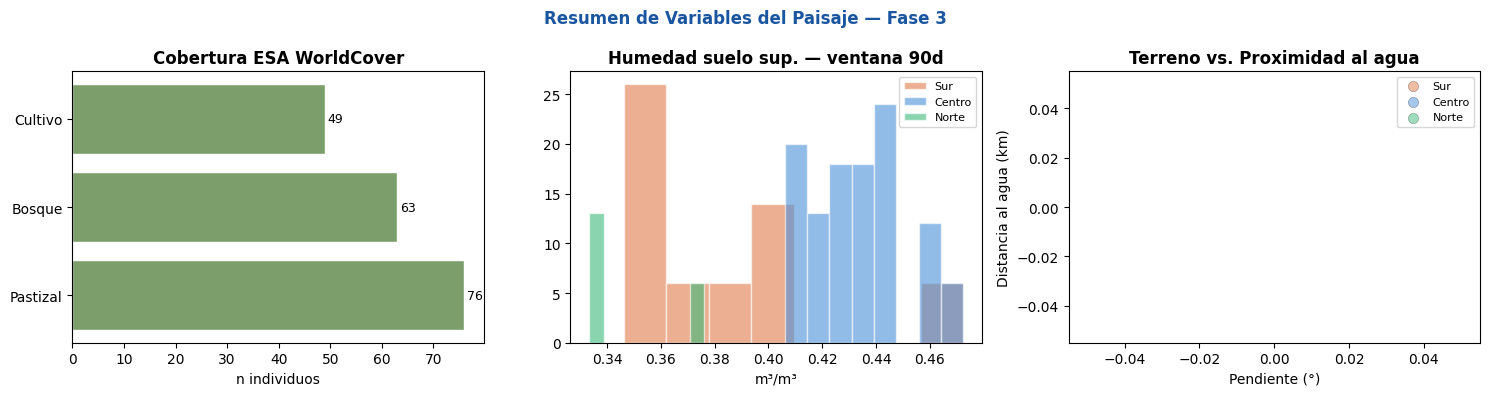

✅ Figura guardada: fase3_paisaje.png
✅ Base maestra exportada: 'fase3_base_maestra.csv'
   188 individuos × 123 variables totales

✅ Fase 3 completada. 'df_master' listo para Fase 4 (modelado de Fitoplasma).


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# FASE 3 — Variables del Paisaje
# ══════════════════════════════════════════════════════════════════════════════

# ─── BLOQUE A: Instalación ────────────────────────────────────────────────────
import subprocess
for paq in ['srtm.py', 'rasterio', 'overpy']:
    subprocess.run(['pip', 'install', paq, '-q'], capture_output=True)

import math
import time
import warnings
import numpy as np
import pandas as pd
import requests
import rasterio
import overpy
import srtm
from rasterio.transform import rowcol as rasterio_rowcol
from datetime import timedelta
warnings.filterwarnings('ignore')

print("✅ Dependencias de Fase 3 instaladas y cargadas")
print(f"   rasterio {rasterio.__version__}  |  overpy {overpy.__version__}")


# ─── BLOQUE B: Humedad y temperatura del suelo — Open-Meteo ERA5-Land ─────────
# leaf_area_index no está disponible en el endpoint histórico de Open-Meteo.
# Se usan variables de suelo confirmadas en la API archive con models=era5_land.

VARS_SUELO_H = [
    'soil_moisture_0_to_7cm',
    'soil_moisture_7_to_28cm',
    'soil_temperature_0_to_7cm',
    'soil_temperature_7_to_28cm',
]


def descargar_suelo(lat, lon, fecha_ini, fecha_fin, reintentos=3):
    """Descargo humedad y temperatura del suelo de Open-Meteo ERA5-Land (horario)."""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        'latitude':   round(lat, 5),
        'longitude':  round(lon, 5),
        'start_date': fecha_ini.strftime('%Y-%m-%d'),
        'end_date':   fecha_fin.strftime('%Y-%m-%d'),
        'hourly':     ','.join(VARS_SUELO_H),
        'models':     'era5_land',    # especificar modelo evita errores 400 en estas variables
        'timezone':   'America/Bogota',
    }
    for intento in range(reintentos):
        try:
            resp = requests.get(url, params=params, timeout=40)
            resp.raise_for_status()
            return resp.json()
        except requests.RequestException as exc:
            if intento < reintentos - 1:
                time.sleep(2 ** intento)
            else:
                raise RuntimeError(f"Descarga suelo fallida: {exc}")


def agregar_suelo_ventana(df_dia, fecha_colecta, n_dias):
    """Estadísticos de humedad y temperatura del suelo para la ventana de n_dias días previos."""
    fecha_fin = fecha_colecta - timedelta(days=1)
    fecha_ini = fecha_colecta - timedelta(days=n_dias)
    sub = df_dia.loc[
        (df_dia['fecha'] >= fecha_ini) & (df_dia['fecha'] <= fecha_fin)
    ].copy()

    if len(sub) == 0:
        return {}

    d   = n_dias
    sm1 = sub['sm_0_7'].dropna()
    sm2 = sub['sm_7_28'].dropna()
    ts1 = sub['ts_0_7'].dropna()
    ts2 = sub['ts_7_28'].dropna()

    # Gradiente vertical de humedad: positivo = suelo superficial más húmedo que profundo
    grad_sm = float(sm1.mean() - sm2.mean()) if (len(sm1) > 0 and len(sm2) > 0) else np.nan

    return {
        f'sm_sup_media_{d}d'   : float(sm1.mean())  if len(sm1) else np.nan,
        f'sm_sup_min_{d}d'     : float(sm1.min())   if len(sm1) else np.nan,
        f'sm_prof_media_{d}d'  : float(sm2.mean())  if len(sm2) else np.nan,
        f'ts_sup_media_{d}d'   : float(ts1.mean())  if len(ts1) else np.nan,
        f'ts_prof_media_{d}d'  : float(ts2.mean())  if len(ts2) else np.nan,
        f'gradiente_sm_{d}d'   : grad_sm,
    }


print("\n🌱 Descargando variables del suelo (Open-Meteo ERA5-Land, models=era5_land) ...")
MAX_VENTANA     = max(VENTANAS_DIAS.values())
registros_suelo = []

for idx, punto in puntos_unicos.iterrows():
    lat           = punto['LAT']
    lon           = punto['LON']
    fecha_colecta = pd.Timestamp(punto['FECHA COLECTA'])
    fecha_ini_dl  = fecha_colecta - pd.Timedelta(days=MAX_VENTANA + 3)

    print(f"  [{idx+1:02d}/{len(puntos_unicos)}] {punto['MUNICIPIO']:20s} ...", end=' ')

    registro = {'LAT': lat, 'LON': lon, 'FECHA COLECTA': fecha_colecta}
    try:
        data = descargar_suelo(lat, lon, fecha_ini_dl, fecha_colecta)
        df_h = pd.DataFrame(data['hourly'])
        df_h['time']  = pd.to_datetime(df_h['time'])
        df_h['fecha'] = df_h['time'].dt.normalize()

        # Agrego las variables horarias a media diaria
        df_dia = (df_h.groupby('fecha')
                      .agg(
                          sm_0_7  =('soil_moisture_0_to_7cm',     'mean'),
                          sm_7_28 =('soil_moisture_7_to_28cm',    'mean'),
                          ts_0_7  =('soil_temperature_0_to_7cm',  'mean'),
                          ts_7_28 =('soil_temperature_7_to_28cm', 'mean'),
                      )
                      .reset_index())

        for nombre_v, dias_v in VENTANAS_DIAS.items():
            agg = agregar_suelo_ventana(df_dia, fecha_colecta, dias_v)
            registro.update(agg)

        registros_suelo.append(registro)
        print("✅")

    except Exception as exc:
        registros_suelo.append(registro)
        print(f"❌ {exc}")

    time.sleep(0.35)

df_suelo = pd.DataFrame(registros_suelo)
print(f"\n  Variables de suelo generadas: {df_suelo.shape[1] - 3}")


# ─── BLOQUE C: Cobertura Terrestre — ESA WorldCover 2021 ─────────────────────
# Lee directamente los GeoTIFF Cloud-Optimized (COG) públicos del bucket S3 de ESA.
# rasterio realiza lectura por ventana: solo descarga el píxel exacto, no el tile completo.

ESA_CLASES = {
    10:  'Bosque',
    20:  'Arbustal',
    30:  'Pastizal',
    40:  'Cultivo',
    50:  'Area_construida',
    60:  'Suelo_desnudo',
    80:  'Cuerpo_agua',
    90:  'Humedal',
    95:  'Manglar',
    100: 'Musgo_liquen',
}


def url_worldcover(lat, lon):
    """Construyo la URL del tile ESA WorldCover 2021 (3°×3°) que contiene el punto."""
    t_lat = int(math.floor(lat / 3)) * 3
    t_lon = int(math.floor(lon / 3)) * 3
    ns    = 'N' if t_lat >= 0 else 'S'
    ew    = 'E' if t_lon >= 0 else 'W'
    tile  = f"{ns}{abs(t_lat):02d}{ew}{abs(t_lon):03d}"
    return (f"https://esa-worldcover.s3.amazonaws.com/v200/2021/map/"
            f"ESA_WorldCover_10m_2021_v200_{tile}_Map.tif"), tile


# Solo proceso las coordenadas únicas: la cobertura no varía por fecha
coords_unicas = puntos_unicos[['LAT', 'LON']].drop_duplicates().reset_index(drop=True)

print("\n🗺️  Extrayendo cobertura ESA WorldCover 2021 (lectura por píxel COG) ...")
tiles_abiertos = {}    # cacho los handles para no releer el mismo tile
resultados_cob = []

for _, fila in coords_unicas.iterrows():
    lat, lon      = fila['LAT'], fila['LON']
    url, tile_nom = url_worldcover(lat, lon)

    try:
        if tile_nom not in tiles_abiertos:
            tiles_abiertos[tile_nom] = rasterio.open(url)
        src = tiles_abiertos[tile_nom]

        r_px, c_px = rasterio_rowcol(src.transform, lon, lat)
        ventana    = rasterio.windows.Window(int(c_px), int(r_px), 1, 1)
        val        = int(src.read(1, window=ventana)[0, 0])
        label      = ESA_CLASES.get(val, f'Clase_{val}')

        resultados_cob.append({
            'LAT': lat, 'LON': lon,
            'worldcover_cod': val, 'worldcover_clase': label
        })
        print(f"  ({lat:.4f}, {lon:.4f}) → {label} [{val}]  ✅")

    except Exception as exc:
        resultados_cob.append({
            'LAT': lat, 'LON': lon,
            'worldcover_cod': np.nan, 'worldcover_clase': 'Desconocido'
        })
        print(f"  ({lat:.4f}, {lon:.4f}) → ❌ {exc}")

for src in tiles_abiertos.values():
    src.close()

df_cob = pd.DataFrame(resultados_cob)
print(f"\n  Distribución de clases: {df_cob['worldcover_clase'].value_counts().to_dict()}")


# ─── BLOQUE D: Terreno — SRTM vía srtm.py ────────────────────────────────────
# srtm.py descarga tiles SRTM3 (90 m) puntuales desde NASA bajo demanda.
# Construyo una vecindad 3×3 alrededor de cada punto y aplico el método de Horn.

print("\n⛰️  Calculando pendiente, aspecto y TRI (SRTM 90 m, método de Horn) ...")
srtm_data = srtm.get_data()

DELTA_DEG = 0.000833    # ≈ 90 m a latitud ~4°N  (1° lat ≈ 111 320 m)
RES_M     = DELTA_DEG * 111_320


def slope_tri_desde_srtm(lat, lon):
    """
    Calculo pendiente (°), aspecto (°) y TRI construyendo una vecindad 3×3
    con valores SRTM y aplicando el método de Horn (1981).
    """
    filas = [lat - DELTA_DEG, lat, lat + DELTA_DEG]
    cols  = [lon - DELTA_DEG, lon, lon + DELTA_DEG]

    z = np.array([
        [srtm_data.get_elevation(r, c) for c in cols]
        for r in filas
    ], dtype=object)

    # Reemplazo None por NaN y convierto a float
    z = np.array([[np.nan if v is None else float(v) for v in fila] for fila in z])

    if np.any(np.isnan(z)):
        return np.nan, np.nan, np.nan

    dzdx = ((z[0,2]+2*z[1,2]+z[2,2]) - (z[0,0]+2*z[1,0]+z[2,0])) / (8 * RES_M)
    dzdy = ((z[2,0]+2*z[2,1]+z[2,2]) - (z[0,0]+2*z[0,1]+z[0,2])) / (8 * RES_M)

    slope  = float(np.degrees(np.arctan(np.sqrt(dzdx**2 + dzdy**2))))
    aspect = float(np.degrees(np.arctan2(dzdy, -dzdx)))
    aspect = aspect + 360 if aspect < 0 else aspect

    centro  = z[1, 1]
    vecinos = np.array([z[i, j] for i in range(3) for j in range(3)
                        if not (i == 1 and j == 1)])
    tri     = float(np.sqrt(np.mean((vecinos - centro) ** 2)))

    return round(slope, 3), round(aspect, 1), round(tri, 3)


resultados_terreno = []
for _, fila in coords_unicas.iterrows():
    lat, lon        = fila['LAT'], fila['LON']
    slope, asp, tri = slope_tri_desde_srtm(lat, lon)
    resultados_terreno.append({
        'LAT': lat, 'LON': lon,
        'slope_grados': slope, 'aspect_grados': asp, 'tri': tri
    })
    estado = "✅" if not np.isnan(slope) else "⚠️ NaN"
    print(f"  ({lat:.4f}, {lon:.4f}) → slope={slope}°  aspect={asp}°  TRI={tri}  {estado}")

df_terreno = pd.DataFrame(resultados_terreno)
print(f"\n  Puntos con terreno calculado: {df_terreno['slope_grados'].notna().sum()}/{len(df_terreno)}")


# ─── BLOQUE E: Distancia a Cuerpos de Agua — OpenStreetMap ───────────────────

def haversine_km(lat1, lon1, lat2, lon2):
    """Distancia en km entre dos coordenadas geográficas (fórmula de Haversine)."""
    R    = 6_371.0
    φ1   = math.radians(lat1)
    φ2   = math.radians(lat2)
    Δφ   = math.radians(lat2 - lat1)
    Δλ   = math.radians(lon2 - lon1)
    a    = math.sin(Δφ/2)**2 + math.cos(φ1) * math.cos(φ2) * math.sin(Δλ/2)**2
    return R * 2 * math.asin(math.sqrt(a))


def distancia_agua_osm(lat, lon, api, radio_m=8_000):
    """
    Consulto Overpass para encontrar el cuerpo de agua más cercano dentro del
    radio dado. Devuelvo la distancia mínima en km; NaN si no se encuentra nada.
    """
    query = f"""
        [out:json][timeout:30];
        (
          way["waterway"~"river|stream|canal|drain"](around:{radio_m},{lat},{lon});
          way["natural"="water"](around:{radio_m},{lat},{lon});
          relation["natural"="water"](around:{radio_m},{lat},{lon});
        );
        out center;
    """
    try:
        resultado = api.query(query)
        dist_min  = float('inf')

        for elem in resultado.ways:
            c_lat = getattr(elem, 'center_lat', None)
            c_lon = getattr(elem, 'center_lon', None)
            if c_lat and c_lon:
                d        = haversine_km(lat, lon, float(c_lat), float(c_lon))
                dist_min = min(dist_min, d)

        return round(dist_min, 3) if dist_min < float('inf') else np.nan

    except Exception:
        return np.nan


print("\n💧 Calculando distancia al agua más cercana (Overpass OSM) ...")
api_osm         = overpy.Overpass()
resultados_agua = []

for _, fila in coords_unicas.iterrows():
    lat, lon = fila['LAT'], fila['LON']
    print(f"  ({lat:.4f}, {lon:.4f}) ...", end=' ')

    dist = distancia_agua_osm(lat, lon, api=api_osm, radio_m=8_000)
    resultados_agua.append({'LAT': lat, 'LON': lon, 'dist_agua_km': dist})

    if not np.isnan(dist):
        print(f"✅  {dist:.2f} km")
    else:
        print("⚠️  sin elemento hídrico en 8 km")

    time.sleep(1.3)    # pausa obligatoria para respetar el rate-limit de Overpass

df_agua = pd.DataFrame(resultados_agua)
print(f"\n  Puntos con agua identificada: {df_agua['dist_agua_km'].notna().sum()}/{len(df_agua)}")


# ─── BLOQUE F: Integración en df_master y exportación ────────────────────────
print("\n🔗 Integrando variables del paisaje en df_master ...")

df_master = (df_master
             .merge(df_suelo,   on=['LAT', 'LON', 'FECHA COLECTA'], how='left')
             .merge(df_cob,     on=['LAT', 'LON'],                  how='left')
             .merge(df_terreno, on=['LAT', 'LON'],                  how='left')
             .merge(df_agua,    on=['LAT', 'LON'],                  how='left'))

# Diagnóstico de cobertura por grupo
grupos_f3 = {
    'Suelo — humedad'    : [c for c in df_master.columns if 'sm_'      in c],
    'Suelo — temperatura': [c for c in df_master.columns if 'ts_suelo' in c or 'ts_sup' in c or 'ts_prof' in c],
    'Cobertura terrestre': ['worldcover_cod', 'worldcover_clase'],
    'Terreno (SRTM)'     : ['slope_grados', 'aspect_grados', 'tri'],
    'Distancia al agua'  : ['dist_agua_km'],
}

print(f"\n{'─'*60}")
print(f"  {'Grupo':<30s}  {'Vars':>4}  {'Nulos%':>7}")
print(f"{'─'*60}")
for grupo, cols in grupos_f3.items():
    existentes = [c for c in cols if c in df_master.columns]
    n          = len(df_master) * len(existentes)
    pct_nulos  = 100 * df_master[existentes].isnull().sum().sum() / n if n > 0 else 0
    print(f"  {grupo:<30s}  {len(existentes):>4}  {pct_nulos:>6.1f}%")
print(f"{'─'*60}")
print(f"  {'DIMENSIÓN TOTAL':<30s}  "
      f"{df_master.shape[0]:>3} filas × {df_master.shape[1]:>3} columnas")

# Gráfica resumen de paisaje
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Resumen de Variables del Paisaje — Fase 3',
             fontweight='bold', color=AZUL_BASE, fontsize=12)

# Panel 1: distribución de coberturas WorldCover
cob_counts = df_master['worldcover_clase'].value_counts()
axes[0].barh(cob_counts.index, cob_counts.values,
             color='#7B9E6B', edgecolor='white')
axes[0].set_title('Cobertura ESA WorldCover', fontweight='bold')
axes[0].set_xlabel('n individuos')
for i, (idx_c, val) in enumerate(cob_counts.items()):
    axes[0].text(val + 0.5, i, str(val), va='center', fontsize=9)

# Panel 2: humedad del suelo superficial (90d) por zona
for zona, color in PALETA_ZONA.items():
    sub = df_master[df_master['ZONA'] == zona]['sm_sup_media_90d'].dropna()
    if len(sub):
        axes[1].hist(sub, bins=8, alpha=0.6, color=color, label=zona, edgecolor='white')
axes[1].set_title('Humedad suelo sup. — ventana 90d', fontweight='bold')
axes[1].set_xlabel('m³/m³')
axes[1].legend(fontsize=8)

# Panel 3: pendiente vs. distancia al agua, coloreado por zona
for zona, color in PALETA_ZONA.items():
    sub = df_master[df_master['ZONA'] == zona]
    axes[2].scatter(sub['slope_grados'], sub['dist_agua_km'],
                    color=color, alpha=0.5, edgecolors='k',
                    linewidths=0.3, s=55, label=zona)
axes[2].set_xlabel('Pendiente (°)')
axes[2].set_ylabel('Distancia al agua (km)')
axes[2].set_title('Terreno vs. Proximidad al agua', fontweight='bold')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Exportar base maestra actualizada
df_master.to_csv('fase3_base_maestra.csv', index=False, encoding='utf-8-sig')
print(f"✅ Base maestra exportada: 'fase3_base_maestra.csv'")
print(f"   {df_master.shape[0]} individuos × {df_master.shape[1]} variables totales")
print("\n✅ Fase 3 completada. 'df_master' listo para Fase 4 (modelado de Fitoplasma).")

<div style="background: linear-gradient(135deg, #5B2C83 0%, #8E44AD 100%); padding: 22px 28px; border-radius: 14px; margin-bottom: 4px;">
  <h1 style="color: white; margin: 0; font-size: 1.65em; letter-spacing: -0.5px;">
    🤖 Fase 4 — Modelado predictivo de Fitoplasma
  </h1>
  <p style="color: #eadcf8; margin: 7px 0 0 0; font-size: 0.95em;">
    Validación GroupKFold por punto de colecta · métricas para datos desbalanceados · selección del mejor modelo
  </p>
</div>

---
# FASE 4
Esta fase entrena modelos únicamente para **Fitoplasma**, porque es el patógeno con frecuencia suficiente para un análisis predictivo. La validación se realiza con grupos de colecta para evitar pseudorreplicación.


⚠️ Variables numéricas retiradas por |r| > 0.90: 63

════════════════════════════════════════════════════════════════════════
  FASE 4 — Preparación del modelado
════════════════════════════════════════════════════════════════════════
Individuos               : 188
Puntos/grupos de colecta  : 30
Fitoplasma positivos      : 129 (68.6%)
Fitoplasma negativos      : 59 (31.4%)
Predictores finales       : 47
  Numéricos               : 41
  Categóricos             : 6

📌 Validación cruzada configurada:
  Fold 1:  37 individuos |  6 grupos | positivos= 24 | negativos= 13
  Fold 2:  33 individuos |  5 grupos | positivos= 26 | negativos=  7
  Fold 3:  36 individuos |  6 grupos | positivos= 26 | negativos= 10
  Fold 4:  45 individuos |  7 grupos | positivos= 26 | negativos= 19
  Fold 5:  37 individuos |  6 grupos | positivos= 27 | negativos= 10

🔁 Entrenando y validando: Logistica_L2
   ROC-AUC=0.660 | PR-AUC=0.769 | Balanced Acc=0.620

🔁 Entrenando y validando: Logistica_L1
   ROC-AUC=0.640 | 

,modelo,roc_auc_media,roc_auc_sd,pr_auc_media,pr_auc_sd,balanced_accuracy_media,sensibilidad_media,especificidad_media,f1_media
4,Random_Forest,0.713530,0.071805,0.820778,0.042672,0.636065,0.521581,0.750549,0.576182
0,CatBoost,0.687105,0.152795,0.831041,0.080867,0.638910,0.746866,0.530954,0.758275
3,Logistica_L2,0.659813,0.082860,0.769096,0.064646,0.620298,0.512464,0.728132,0.596574
2,Logistica_L1,0.639865,0.088769,0.772627,0.059372,0.580738,0.404772,0.756703,0.504606
1,HistGradientBoosting,0.630351,0.067665,0.777467,0.068303,0.578975,0.638818,0.519132,0.676324



📊 Métricas con IC95% bootstrap agrupado:


,modelo,roc_auc_media,roc_auc_sd,pr_auc_media,pr_auc_sd,balanced_accuracy_media,sensibilidad_media,especificidad_media,f1_media,roc_auc_ic95_inf,roc_auc_ic95_sup,pr_auc_ic95_inf,pr_auc_ic95_sup
0,Random_Forest,0.713530,0.071805,0.820778,0.042672,0.636065,0.521581,0.750549,0.576182,0.584953,0.804731,0.713195,0.894322
1,CatBoost,0.687105,0.152795,0.831041,0.080867,0.638910,0.746866,0.530954,0.758275,0.534195,0.783181,0.714609,0.899971
2,Logistica_L2,0.659813,0.082860,0.769096,0.064646,0.620298,0.512464,0.728132,0.596574,0.524324,0.780977,0.702208,0.867719
3,Logistica_L1,0.639865,0.088769,0.772627,0.059372,0.580738,0.404772,0.756703,0.504606,0.526329,0.780947,0.701998,0.867533
4,HistGradientBoosting,0.630351,0.067665,0.777467,0.068303,0.578975,0.638818,0.519132,0.676324,0.472853,0.718074,0.638344,0.867681



════════════════════════════════════════════════════════════════════════
  Mejor modelo seleccionado
════════════════════════════════════════════════════════════════════════
Modelo       : Random_Forest
Criterio     : roc_auc_media
Predictores  : 47
Grupos       : 30

✅ Archivos guardados:
  - fase4_5_resultados/fase4_modelo_mejor_fitoplasma.joblib
  - fase4_5_resultados/fase4_metricas_modelos.csv
  - fase4_5_resultados/fase4_metricas_por_fold.csv
  - fase4_5_resultados/fase4_predicciones_oof.csv
  - fase4_5_resultados/fase4_base_modelado.csv
  - fase4_5_resultados/fase4_metadata_modelado.json


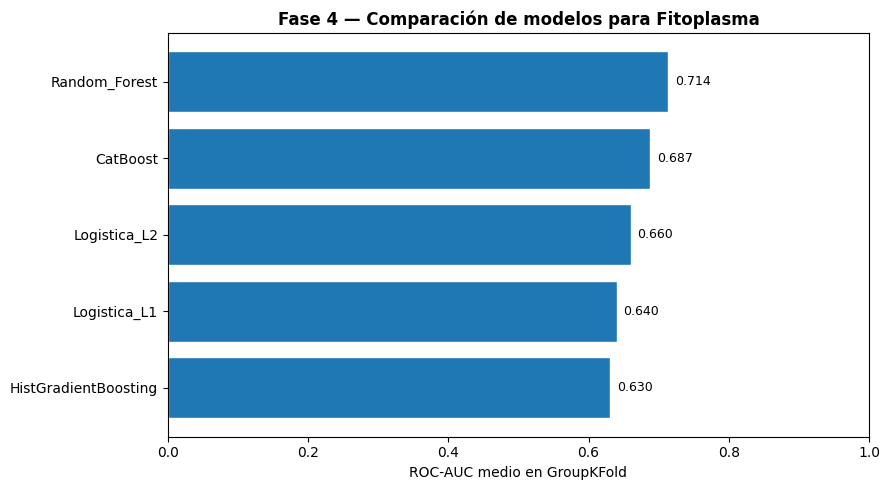


✅ GAM exploratorio ajustado con variables:
['LON', 'LAT', 'ALTITUD_M', 'dias_lluvia_30d', 't_min_7d', 'racha_seca_30d']

✅ Fase 4 completada. 'final_model' queda listo para Fase 5.


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# FASE 4 — Modelado predictivo de Fitoplasma
# ══════════════════════════════════════════════════════════════════════════════

# ── Instalación de dependencias opcionales ───────────────────────────────────
# Mantengo el bloque en modo seguro: si CatBoost, SHAP o pyGAM no instalan,
# el cuaderno continúa con modelos base de scikit-learn.
import sys
import subprocess
import importlib
import inspect
import json
import re
from pathlib import Path

def instalar_si_falta(paquete, import_name=None):
    """Instalo una dependencia solo cuando no está disponible en el entorno."""
    import_name = import_name or paquete
    try:
        return importlib.import_module(import_name)
    except Exception:
        print(f"📦 Instalando {paquete} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", paquete, "-q"], check=False)
        try:
            return importlib.import_module(import_name)
        except Exception as exc:
            print(f"⚠️ No se pudo cargar {paquete}: {exc}")
            return None

catboost_mod = instalar_si_falta("catboost", "catboost")
pygam_mod    = instalar_si_falta("pygam", "pygam")

# ── Librerías principales ────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display, HTML

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.exceptions import NotFittedError
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

try:
    from sklearn.model_selection import StratifiedGroupKFold
    TIENE_STRATIFIED_GROUP = True
except Exception:
    TIENE_STRATIFIED_GROUP = False

RANDOM_STATE = 42
CARPETA_SALIDA = Path("fase4_5_resultados")
CARPETA_SALIDA.mkdir(exist_ok=True)

# ── Recuperación de la base maestra ──────────────────────────────────────────
# Uso df_master si viene de las fases previas. Si no existe, cargo el respaldo CSV.
if "df_master" not in globals():
    ruta_respaldo = Path("fase3_base_maestra.csv")
    if not ruta_respaldo.exists():
        raise FileNotFoundError(
            "No encuentro df_master ni fase3_base_maestra.csv. "
            "Ejecuta primero las fases 1, 2 y 3."
        )
    df_master = pd.read_csv(ruta_respaldo, encoding="utf-8-sig")

df_model = df_master.copy()
df_model.columns = [str(c).strip() for c in df_model.columns]

# Aseguro tipo de fecha y creo variables temporales interpretables.
if "FECHA COLECTA" in df_model.columns:
    df_model["FECHA COLECTA"] = pd.to_datetime(df_model["FECHA COLECTA"], errors="coerce")
    df_model["doy_colecta"] = df_model["FECHA COLECTA"].dt.dayofyear
    df_model["mes_colecta"] = df_model["FECHA COLECTA"].dt.month
    df_model["semana_iso_colecta"] = df_model["FECHA COLECTA"].dt.isocalendar().week.astype("float")

# Creo identificador de punto de colecta para controlar pseudorreplicación.
cols_grupo_candidatas = [
    c for c in ["MUNICIPIO", "VEREDA", "FECHA COLECTA", "LAT", "LON"]
    if c in df_model.columns
]
if len(cols_grupo_candidatas) < 3:
    raise ValueError(
        "No hay suficientes columnas para construir el grupo de colecta. "
        "Se requieren al menos municipio/vereda/fecha/coordenadas."
    )

df_model["grupo_colecta"] = (
    df_model[cols_grupo_candidatas]
    .astype(str)
    .agg(" | ".join, axis=1)
)

TARGET_FITO = "FITOPLASMA"
TARGET_ESPIRO = "ESPIROPLASMA"

if TARGET_FITO not in df_model.columns:
    raise ValueError("No encuentro la columna FITOPLASMA. Revisa el renombramiento de la Fase 1.")

df_model[TARGET_FITO] = pd.to_numeric(df_model[TARGET_FITO], errors="coerce").astype("Int64")
df_model = df_model.dropna(subset=[TARGET_FITO, "grupo_colecta"]).copy()
df_model[TARGET_FITO] = df_model[TARGET_FITO].astype(int)

# ── Definición de variables predictoras ──────────────────────────────────────
# Elimino columnas que causarían fuga de información o que no aportan al modelo.
patrones_exclusion = [
    r"^FITOPLASMA$",
    r"^ESPIROPLASMA$",
    r"^grupo_colecta$",
    r"^INDIVIDUO$",
    r"^INDIVIDUO No\.$",
    r"^FECHA COLECTA$",
    r"^DEPARTAMENTO$",
    r"n_fitoplasma",
    r"pct_fito",
    r"n_espiro",
    r"n_indiv",
    r"positivos",
    r"total",
]

def es_columna_excluida(col):
    """Reviso si una columna debe salir del set de predictores."""
    return any(re.search(p, col, flags=re.IGNORECASE) for p in patrones_exclusion)

feature_cols = [c for c in df_model.columns if not es_columna_excluida(c)]

# Elimino columnas vacías o con un único valor real.
feature_cols = [
    c for c in feature_cols
    if df_model[c].notna().sum() > 0 and df_model[c].nunique(dropna=True) > 1
]

# Elimino columnas con demasiados nulos, porque pueden volver inestable el ajuste.
umbral_nulos = 0.40
cols_muchos_nulos = [
    c for c in feature_cols
    if df_model[c].isna().mean() > umbral_nulos
]
feature_cols = [c for c in feature_cols if c not in cols_muchos_nulos]

X = df_model[feature_cols].copy()
y = df_model[TARGET_FITO].astype(int).copy()
groups = df_model["grupo_colecta"].copy()

numeric_cols = [
    c for c in feature_cols
    if pd.api.types.is_numeric_dtype(df_model[c])
]
cat_cols = [c for c in feature_cols if c not in numeric_cols]

# ── Filtro de colinealidad alta en variables numéricas ───────────────────────
def columnas_colineales_a_eliminar(df_base, columnas, umbral=0.90):
    """Identifico variables numéricas redundantes por correlación absoluta."""
    if len(columnas) < 2:
        return []

    tmp = df_base[columnas].copy()
    tmp = tmp.apply(pd.to_numeric, errors="coerce")
    tmp = tmp.fillna(tmp.median(numeric_only=True))

    corr = tmp.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    eliminar = []
    for col in upper.columns:
        if any(upper[col] > umbral):
            eliminar.append(col)
    return eliminar

cols_colineales = columnas_colineales_a_eliminar(df_model, numeric_cols, umbral=0.90)

if cols_colineales:
    print(f"⚠️ Variables numéricas retiradas por |r| > 0.90: {len(cols_colineales)}")
    feature_cols = [c for c in feature_cols if c not in cols_colineales]
    numeric_cols = [c for c in numeric_cols if c not in cols_colineales]
    cat_cols = [c for c in cat_cols if c not in cols_colineales]
    X = df_model[feature_cols].copy()

# Convierto categóricas a texto para evitar errores de codificación mixta.
for c in cat_cols:
    X[c] = X[c].astype("string")

print("\n" + "═"*72)
print("  FASE 4 — Preparación del modelado")
print("═"*72)
print(f"Individuos               : {len(df_model)}")
print(f"Puntos/grupos de colecta  : {groups.nunique()}")
print(f"Fitoplasma positivos      : {int(y.sum())} ({100*y.mean():.1f}%)")
print(f"Fitoplasma negativos      : {int((1-y).sum())} ({100*(1-y.mean()):.1f}%)")
print(f"Predictores finales       : {len(feature_cols)}")
print(f"  Numéricos               : {len(numeric_cols)}")
print(f"  Categóricos             : {len(cat_cols)}")
if cols_muchos_nulos:
    print(f"Variables retiradas por nulos > {umbral_nulos:.0%}: {len(cols_muchos_nulos)}")

# ── Preprocesamiento ─────────────────────────────────────────────────────────
def crear_onehot_encoder():
    """Creo OneHotEncoder compatible con distintas versiones de scikit-learn."""
    params = {"handle_unknown": "ignore"}
    if "sparse_output" in inspect.signature(OneHotEncoder).parameters:
        params["sparse_output"] = False
    else:
        params["sparse"] = False
    return OneHotEncoder(**params)

preprocess_linear = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", crear_onehot_encoder()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", crear_onehot_encoder()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

# ── Modelos ──────────────────────────────────────────────────────────────────
MODELOS = {}

MODELOS["Logistica_L2"] = Pipeline([
    ("preprocess", preprocess_linear),
    ("modelo", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE,
    )),
])

MODELOS["Logistica_L1"] = Pipeline([
    ("preprocess", preprocess_linear),
    ("modelo", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE,
    )),
])

MODELOS["Random_Forest"] = Pipeline([
    ("preprocess", preprocess_tree),
    ("modelo", RandomForestClassifier(
        n_estimators=600,
        max_depth=4,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

MODELOS["HistGradientBoosting"] = Pipeline([
    ("preprocess", preprocess_tree),
    ("modelo", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.035,
        max_leaf_nodes=7,
        l2_regularization=0.10,
        random_state=RANDOM_STATE,
    )),
])

if catboost_mod is not None:
    from catboost import CatBoostClassifier
    MODELOS["CatBoost"] = Pipeline([
        ("preprocess", preprocess_tree),
        ("modelo", CatBoostClassifier(
            iterations=450,
            depth=3,
            learning_rate=0.035,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        )),
    ])

# ── Métricas y validación GroupKFold ─────────────────────────────────────────
def probabilidad_positiva(modelo, X_eval):
    """Obtengo la probabilidad de clase positiva de forma robusta."""
    if hasattr(modelo, "predict_proba"):
        proba = modelo.predict_proba(X_eval)
        return proba[:, 1]
    if hasattr(modelo, "decision_function"):
        score = modelo.decision_function(X_eval)
        return 1 / (1 + np.exp(-score))
    pred = modelo.predict(X_eval)
    return pred.astype(float)

def metricas_binarias(y_true, y_prob, umbral=0.50):
    """Calculo métricas adecuadas para clasificación desbalanceada."""
    y_pred = (y_prob >= umbral).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "sensibilidad_recall": recall_score(y_true, y_pred, zero_division=0),
        "especificidad": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": np.nan,
        "pr_auc": np.nan,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
    }

    if len(np.unique(y_true)) == 2:
        out["roc_auc"] = roc_auc_score(y_true, y_prob)
        out["pr_auc"] = average_precision_score(y_true, y_prob)

    return out

def crear_folds(X_base, y_base, grupos, n_splits=5):
    """Creo folds agrupados; uso estratificación si la versión de sklearn lo permite."""
    n_grupos = grupos.nunique()
    n_splits = min(n_splits, n_grupos)

    if TIENE_STRATIFIED_GROUP:
        splitter = StratifiedGroupKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=RANDOM_STATE,
        )
        return list(splitter.split(X_base, y_base, groups=grupos))

    splitter = GroupKFold(n_splits=n_splits)
    return list(splitter.split(X_base, y_base, groups=grupos))

def evaluar_modelo_groupcv(nombre, pipeline, X_base, y_base, grupos, folds):
    """Evalúo un modelo con validación cruzada agrupada por punto de colecta."""
    registros = []
    pred_oof = pd.DataFrame({
        "row_id": np.arange(len(y_base)),
        "y_true": y_base.values,
        "grupo_colecta": grupos.values,
        "modelo": nombre,
        "y_prob": np.nan,
        "fold": np.nan,
    })

    for k, (idx_train, idx_test) in enumerate(folds, start=1):
        X_train, X_test = X_base.iloc[idx_train], X_base.iloc[idx_test]
        y_train, y_test = y_base.iloc[idx_train], y_base.iloc[idx_test]

        modelo = clone(pipeline)
        pesos_train = compute_sample_weight(class_weight="balanced", y=y_train)

        try:
            modelo.fit(X_train, y_train, modelo__sample_weight=pesos_train)
        except TypeError:
            # Algunos estimadores ignoran sample_weight; ajusto sin romper el flujo.
            modelo.fit(X_train, y_train)

        y_prob = probabilidad_positiva(modelo, X_test)
        mets = metricas_binarias(y_test.values, y_prob)
        mets.update({
            "modelo": nombre,
            "fold": k,
            "n_train": len(idx_train),
            "n_test": len(idx_test),
            "grupos_test": grupos.iloc[idx_test].nunique(),
            "positivos_test": int(y_test.sum()),
            "negativos_test": int((1 - y_test).sum()),
        })
        registros.append(mets)

        pred_oof.loc[idx_test, "y_prob"] = y_prob
        pred_oof.loc[idx_test, "fold"] = k

    return pd.DataFrame(registros), pred_oof

folds = crear_folds(X, y, groups, n_splits=5)

print("\n📌 Validación cruzada configurada:")
for k, (_, idx_test) in enumerate(folds, start=1):
    print(
        f"  Fold {k}: {len(idx_test):3d} individuos | "
        f"{groups.iloc[idx_test].nunique():2d} grupos | "
        f"positivos={int(y.iloc[idx_test].sum()):3d} | "
        f"negativos={int((1-y.iloc[idx_test]).sum()):3d}"
    )

resultados_folds = []
predicciones_oof = []

for nombre, pipe in MODELOS.items():
    print(f"\n🔁 Entrenando y validando: {nombre}")
    try:
        res_fold, pred_oof = evaluar_modelo_groupcv(nombre, pipe, X, y, groups, folds)
        resultados_folds.append(res_fold)
        predicciones_oof.append(pred_oof)
        print(
            f"   ROC-AUC={res_fold['roc_auc'].mean(skipna=True):.3f} | "
            f"PR-AUC={res_fold['pr_auc'].mean(skipna=True):.3f} | "
            f"Balanced Acc={res_fold['balanced_accuracy'].mean(skipna=True):.3f}"
        )
    except Exception as exc:
        print(f"   ⚠️ Modelo omitido por error: {exc}")

resultados_folds = pd.concat(resultados_folds, ignore_index=True)
predicciones_oof = pd.concat(predicciones_oof, ignore_index=True)

metricas_resumen = (
    resultados_folds
    .groupby("modelo")
    .agg(
        roc_auc_media=("roc_auc", "mean"),
        roc_auc_sd=("roc_auc", "std"),
        pr_auc_media=("pr_auc", "mean"),
        pr_auc_sd=("pr_auc", "std"),
        balanced_accuracy_media=("balanced_accuracy", "mean"),
        sensibilidad_media=("sensibilidad_recall", "mean"),
        especificidad_media=("especificidad", "mean"),
        f1_media=("f1", "mean"),
    )
    .reset_index()
    .sort_values(["roc_auc_media", "pr_auc_media", "balanced_accuracy_media"], ascending=False)
)

print("\n" + "═"*72)
print("  Comparación de modelos — validación GroupKFold")
print("═"*72)
display(metricas_resumen)

# ── Intervalos de confianza por bootstrap agrupado ───────────────────────────
def bootstrap_ci_grouped(y_true, y_prob, grupos, metric_fn, n_boot=1000, seed=RANDOM_STATE):
    """Calculo intervalo bootstrap remuestreando grupos completos de colecta."""
    rng = np.random.default_rng(seed)
    base = pd.DataFrame({
        "y": np.asarray(y_true),
        "p": np.asarray(y_prob),
        "g": np.asarray(grupos),
    })
    grupos_unicos = base["g"].dropna().unique()
    vals = []

    for _ in range(n_boot):
        sample_groups = rng.choice(grupos_unicos, size=len(grupos_unicos), replace=True)
        boot = pd.concat([base[base["g"] == g] for g in sample_groups], ignore_index=True)
        if boot["y"].nunique() < 2:
            continue
        try:
            vals.append(metric_fn(boot["y"], boot["p"]))
        except Exception:
            continue

    if not vals:
        return np.nan, np.nan

    return np.percentile(vals, [2.5, 97.5])

filas_ci = []
for nombre in metricas_resumen["modelo"]:
    tmp = predicciones_oof[predicciones_oof["modelo"] == nombre].dropna(subset=["y_prob"])
    roc_li, roc_ls = bootstrap_ci_grouped(tmp["y_true"], tmp["y_prob"], tmp["grupo_colecta"], roc_auc_score)
    pr_li, pr_ls   = bootstrap_ci_grouped(tmp["y_true"], tmp["y_prob"], tmp["grupo_colecta"], average_precision_score)

    filas_ci.append({
        "modelo": nombre,
        "roc_auc_ic95_inf": roc_li,
        "roc_auc_ic95_sup": roc_ls,
        "pr_auc_ic95_inf": pr_li,
        "pr_auc_ic95_sup": pr_ls,
    })

ci_modelos = pd.DataFrame(filas_ci)
metricas_resumen = metricas_resumen.merge(ci_modelos, on="modelo", how="left")

print("\n📊 Métricas con IC95% bootstrap agrupado:")
display(metricas_resumen)

# ── Selección y ajuste final del mejor modelo ────────────────────────────────
# Priorizo ROC-AUC; si estuviera vacío, uso PR-AUC y luego balanced accuracy.
criterios = ["roc_auc_media", "pr_auc_media", "balanced_accuracy_media"]
metricas_validas = metricas_resumen.copy()

for criterio in criterios:
    if metricas_validas[criterio].notna().any():
        nombre_mejor = (
            metricas_validas
            .sort_values(criterio, ascending=False)
            .iloc[0]["modelo"]
        )
        criterio_usado = criterio
        break

final_model = clone(MODELOS[nombre_mejor])
pesos_full = compute_sample_weight(class_weight="balanced", y=y)

try:
    final_model.fit(X, y, modelo__sample_weight=pesos_full)
except TypeError:
    final_model.fit(X, y)

print("\n" + "═"*72)
print("  Mejor modelo seleccionado")
print("═"*72)
print(f"Modelo       : {nombre_mejor}")
print(f"Criterio     : {criterio_usado}")
print(f"Predictores  : {len(feature_cols)}")
print(f"Grupos       : {groups.nunique()}")

# ── Exportación de resultados de Fase 4 ──────────────────────────────────────
ruta_modelo = CARPETA_SALIDA / "fase4_modelo_mejor_fitoplasma.joblib"
ruta_metricas = CARPETA_SALIDA / "fase4_metricas_modelos.csv"
ruta_folds = CARPETA_SALIDA / "fase4_metricas_por_fold.csv"
ruta_oof = CARPETA_SALIDA / "fase4_predicciones_oof.csv"
ruta_base = CARPETA_SALIDA / "fase4_base_modelado.csv"
ruta_metadata = CARPETA_SALIDA / "fase4_metadata_modelado.json"

joblib.dump(final_model, ruta_modelo)
metricas_resumen.to_csv(ruta_metricas, index=False, encoding="utf-8-sig")
resultados_folds.to_csv(ruta_folds, index=False, encoding="utf-8-sig")
predicciones_oof.to_csv(ruta_oof, index=False, encoding="utf-8-sig")
df_model.to_csv(ruta_base, index=False, encoding="utf-8-sig")

metadata_modelado = {
    "target_fitoplasma": TARGET_FITO,
    "target_espiroplasma": TARGET_ESPIRO,
    "modelo_seleccionado": nombre_mejor,
    "criterio_seleccion": criterio_usado,
    "feature_cols": feature_cols,
    "numeric_cols": numeric_cols,
    "cat_cols": cat_cols,
    "group_col": "grupo_colecta",
    "cols_grupo_candidatas": cols_grupo_candidatas,
    "cols_retiradas_muchos_nulos": cols_muchos_nulos,
    "cols_retiradas_colineales": cols_colineales,
    "n_individuos": int(len(df_model)),
    "n_grupos": int(groups.nunique()),
}

with open(ruta_metadata, "w", encoding="utf-8") as f:
    json.dump(metadata_modelado, f, ensure_ascii=False, indent=2, default=str)

print("\n✅ Archivos guardados:")
for ruta in [ruta_modelo, ruta_metricas, ruta_folds, ruta_oof, ruta_base, ruta_metadata]:
    print(f"  - {ruta}")

# ── Gráfica comparativa de modelos ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = metricas_resumen.sort_values("roc_auc_media", ascending=True)
ax.barh(plot_df["modelo"], plot_df["roc_auc_media"], edgecolor="white")
ax.set_xlabel("ROC-AUC medio en GroupKFold")
ax.set_title("Fase 4 — Comparación de modelos para Fitoplasma", fontweight="bold")
ax.set_xlim(0, 1)
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["roc_auc_media"] + 0.01 if pd.notna(row["roc_auc_media"]) else 0.01,
        i,
        f"{row['roc_auc_media']:.3f}" if pd.notna(row["roc_auc_media"]) else "NA",
        va="center",
        fontsize=9,
    )
plt.tight_layout()
plt.savefig(CARPETA_SALIDA / "fase4_comparacion_modelos_fitoplasma.png", dpi=150, bbox_inches="tight")
plt.show()

# ── GAM exploratorio opcional ────────────────────────────────────────────────
# pyGAM se usa solo como apoyo interpretativo, no como reemplazo del pipeline principal.
if pygam_mod is not None and len(numeric_cols) >= 2:
    try:
        from pygam import LogisticGAM, s

        # Selecciono hasta 6 variables numéricas con mayor asociación absoluta simple.
        corr_simple = (
            df_model[numeric_cols + [TARGET_FITO]]
            .corr(numeric_only=True)[TARGET_FITO]
            .drop(TARGET_FITO)
            .dropna()
            .abs()
            .sort_values(ascending=False)
        )
        vars_gam = corr_simple.head(min(6, len(corr_simple))).index.tolist()

        X_gam = df_model[vars_gam].copy()
        X_gam = X_gam.fillna(X_gam.median(numeric_only=True))
        y_gam = y.values

        terms = s(0)
        for i in range(1, len(vars_gam)):
            terms += s(i)

        gam = LogisticGAM(terms, max_iter=300).fit(X_gam.values, y_gam)

        print("\n✅ GAM exploratorio ajustado con variables:")
        print(vars_gam)

        joblib.dump({"modelo": gam, "variables": vars_gam}, CARPETA_SALIDA / "fase4_gam_exploratorio.joblib")

    except Exception as exc:
        print(f"\n⚠️ GAM exploratorio no ajustado: {exc}")

print("\n✅ Fase 4 completada. 'final_model' queda listo para Fase 5.")


<div style="background: linear-gradient(135deg, #8B1E3F 0%, #D1495B 100%); padding: 22px 28px; border-radius: 14px; margin-bottom: 4px;">
  <h1 style="color: white; margin: 0; font-size: 1.65em; letter-spacing: -0.5px;">
    🔍 Fase 5 — Interpretabilidad y Espiroplasma
  </h1>
  <p style="color: #ffdce5; margin: 7px 0 0 0; font-size: 0.95em;">
    SHAP · importancia por permutación · dependencia parcial · análisis descriptivo de los positivos de Espiroplasma
  </p>
</div>

---
# FASE 5
Esta fase interpreta el mejor modelo de Fitoplasma y mantiene Espiroplasma como análisis descriptivo, sin entrenamiento predictivo, por el número mínimo de positivos.



════════════════════════════════════════════════════════════════════════════
  FASE 5 — Interpretabilidad y descripción de Espiroplasma
════════════════════════════════════════════════════════════════════════════
Modelo interpretado : Random_Forest
Individuos          : 188
Predictores         : 47

🔎 Calculando importancia por permutación sobre variables originales ...


,variable,importancia_media_pr_auc,importancia_sd
0,MORFOTIPO,0.003428,0.001318
1,ALTITUD_M,0.002776,0.002323
2,worldcover_clase,0.002325,0.002313
3,SEXO,0.002215,0.001052
4,LON,0.002057,0.002414
5,tri,0.001974,0.001492
6,t_min_7d,0.001682,0.002357
7,slope_grados,0.001517,0.001669
8,LAT,0.001425,0.001938
9,aspect_grados,0.001334,0.001618


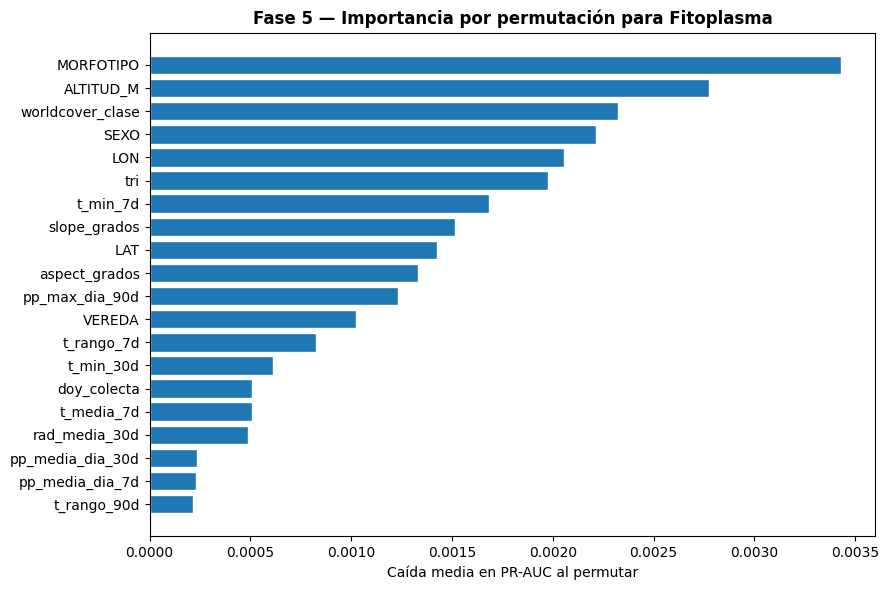


🧠 Calculando SHAP con 188 observaciones ...
⚠️ SHAP no se pudo calcular en este entorno: Per-column arrays must each be 1-dimensional

📈 Generando curvas de dependencia parcial para:
['ALTITUD_M', 'LON', 'tri', 't_min_7d', 'slope_grados', 'LAT']


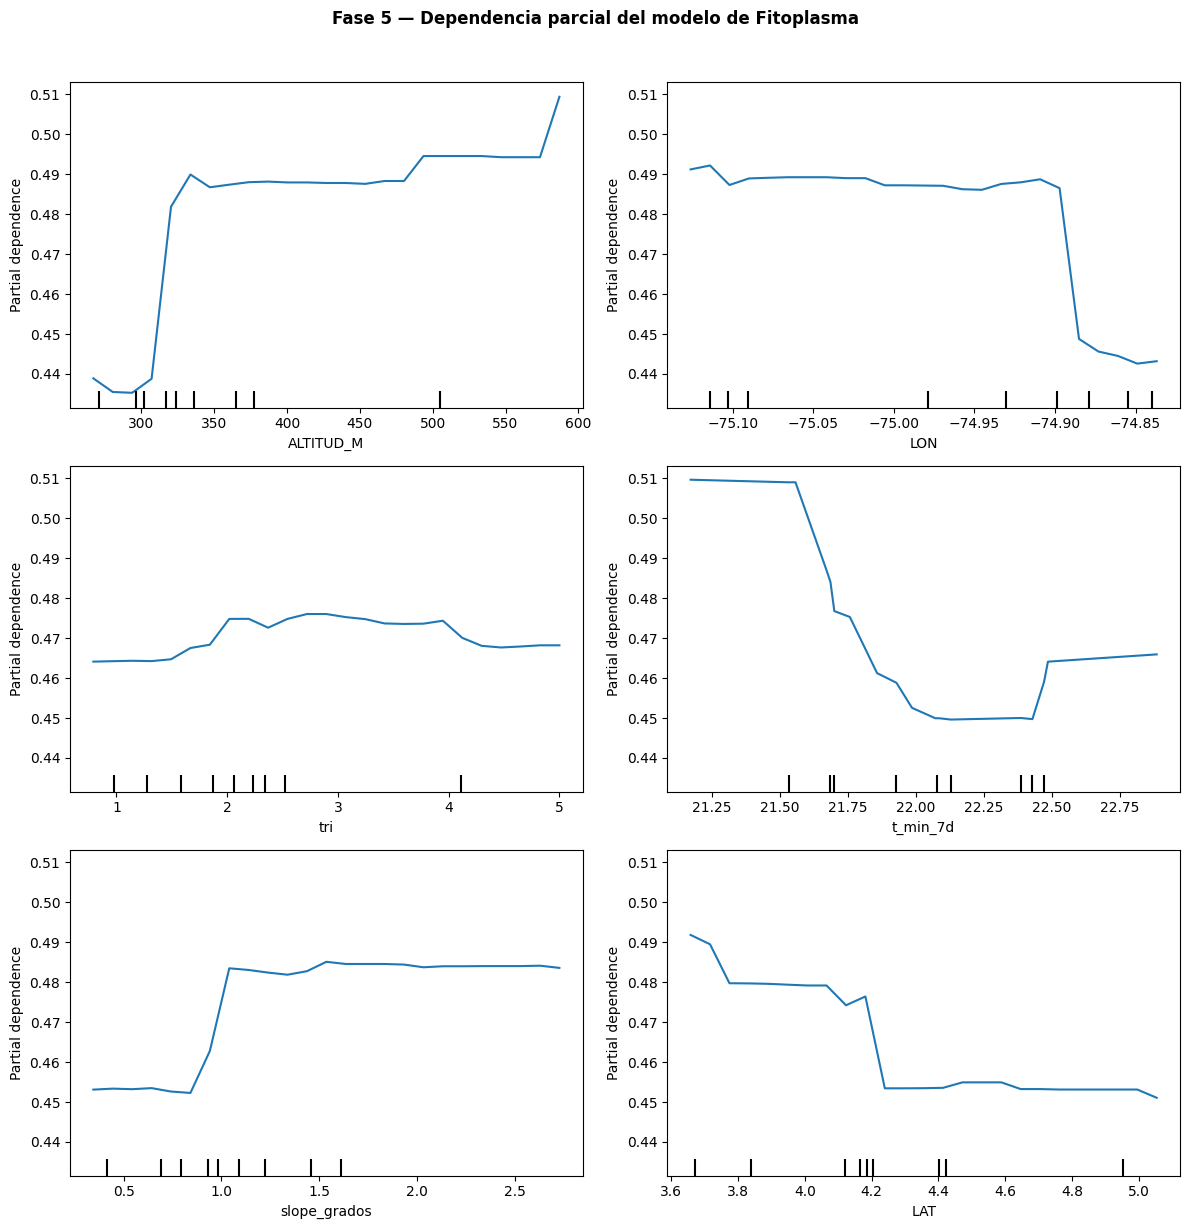


════════════════════════════════════════════════════════════════════════════
ADVERTENCIA METODOLÓGICA — ESPIROPLASMA
Solo hay 3 individuos positivos frente a 185 negativos.
Con esta frecuencia no es metodológicamente defendible entrenar un modelo
predictivo: el clasificador tendería a aprender la clase mayoritaria y cualquier
métrica de exactitud sería engañosa. Por tanto, esta fase realiza análisis
descriptivo y exploratorio de los positivos, sin inferencia causal ni predicción.
════════════════════════════════════════════════════════════════════════════

🧬 Individuos positivos para Espiroplasma:


,ZONA,MUNICIPIO,VEREDA,FECHA COLECTA,LAT,LON,ALTITUD_M,SEXO,MORFOTIPO,FITOPLASMA,ESPIROPLASMA,fase_enso_mes_colecta,fase_enso_trim_previo,dist_agua_km
0,Centro,Alvarado,Rincón de Chipalo,2025-07-02,4.59823,-74.90772,338,Macho,Morfotipo II,1,1,Neutro,Neutro,NaN
1,Sur,Coyaima,Castilla,2025-06-25,3.83066,-75.09468,324,Macho,Morfotipo II,1,1,Neutro,Neutro,NaN
2,Sur,Guamo,Serrezuela,2025-06-19,4.07825,-74.93053,317,Hembra,Morfotipo I,0,1,Neutro,Neutro,NaN



📋 Distribución: ZONA × Espiroplasma


,espiro_0,espiro_1,espiro_All
ZONA,,,
Centro,110,1,111
Norte,19,0,19
Sur,56,2,58
All,185,3,188



📋 Distribución: MUNICIPIO × Espiroplasma


...

,espiro_0,espiro_1,espiro_All
fase_enso_trim_previo,,,
Neutro,185,3,188
All,185,3,188



📊 Variables numéricas con mayor diferencia descriptiva en Espiroplasma:


,variable,media_espiro_pos,media_espiro_neg,diferencia_pos_menos_neg,dif_estandarizada,n_pos_validos,n_neg_validos
0,t_rango_90d,8.759259,8.381171,0.378088,1.227668,3,185
1,t_rango_7d,9.271429,8.445328,0.826100,0.906391,3,185
2,sol_horas_90d,947.601151,932.532157,15.068994,0.847130,3,185
3,viento_media_7d,7.552381,6.526641,1.025740,0.793613,3,185
4,sol_horas_7d,78.447806,75.780979,2.666828,0.723150,3,185
5,t_media_7d,26.209524,25.866564,0.342960,0.714045,3,185
6,pp_media_dia_30d,2.432222,3.144847,-0.712625,-0.699261,3,185
7,t_min_30d,22.064444,22.250667,-0.186222,-0.652192,3,185
8,doy_colecta,176.333333,172.389189,3.944144,0.636842,3,185
9,sol_horas_30d,324.962746,319.421675,5.541071,0.622270,3,185



🧪 Fisher exact exploratorio por categoría/nivel:


,variable,nivel,pos_en_nivel,pos_fuera_nivel,neg_en_nivel,neg_fuera_nivel,odds_ratio_exploratorio,p_value_exploratorio
0,VEREDA,Castilla,1,2,5,180,18.000000,0.093203
1,VEREDA,Rincón de Chipalo,1,2,5,180,18.000000,0.093203
2,VEREDA,Serrezuela,1,2,6,179,14.916667,0.108150
3,SEXO,Macho,2,1,48,137,5.708333,0.173099
4,SEXO,Hembra,1,2,137,48,0.175182,0.173099
5,ZONA,Sur,2,1,56,129,4.607143,0.225489
6,MORFOTIPO,Morfotipo II,2,1,60,125,4.166667,0.253328
7,MUNICIPIO,Alvarado,1,2,17,168,4.941176,0.261871
8,MUNICIPIO,Guamo,1,2,19,166,4.368421,0.287768
9,MUNICIPIO,Coyaima,1,2,19,166,4.368421,0.287768


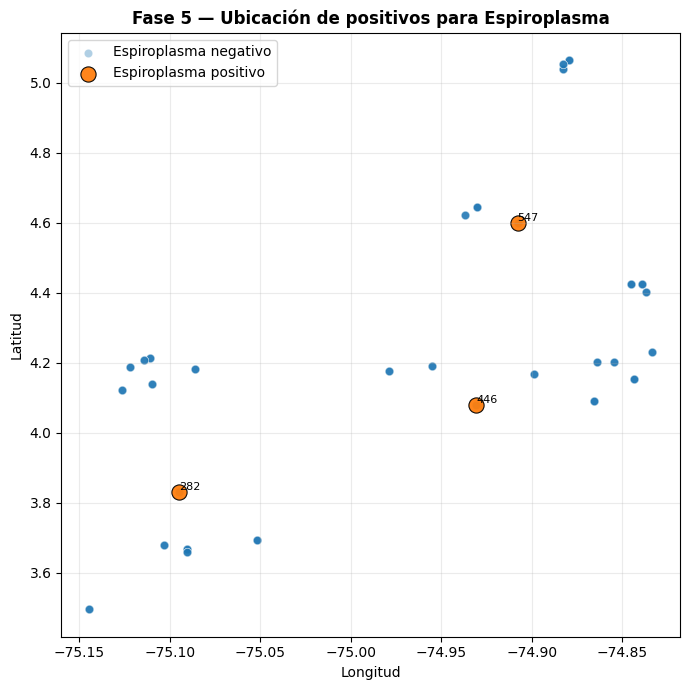

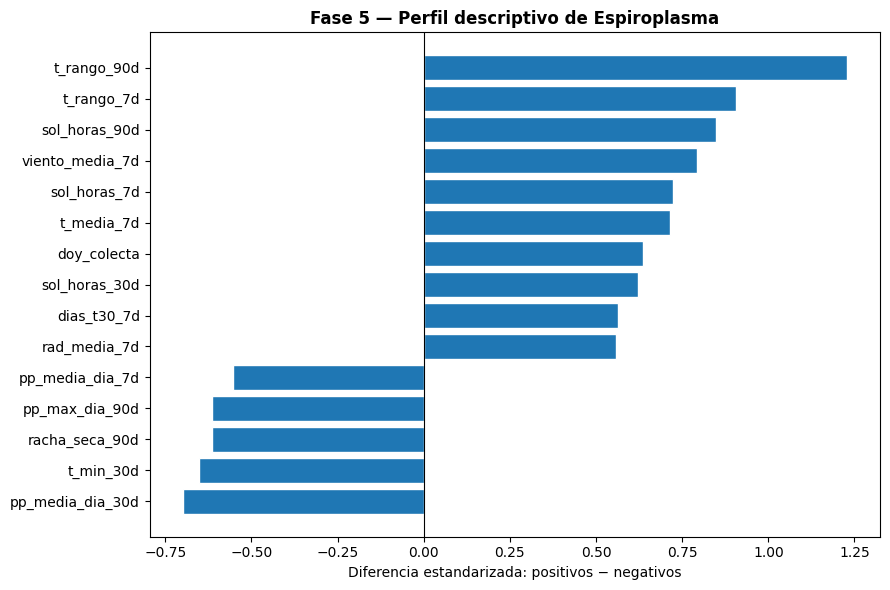


✅ Fase 5 completada. Resultados guardados en la carpeta:
   /content/fase4_5_resultados


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# FASE 5 — Interpretabilidad de Fitoplasma y análisis descriptivo de Espiroplasma
# ══════════════════════════════════════════════════════════════════════════════

# ── Instalación/carga de SHAP ────────────────────────────────────────────────
import sys
import subprocess
import importlib
import json
import re
from pathlib import Path

def instalar_si_falta(paquete, import_name=None):
    """Instalo una dependencia solo cuando no está disponible en el entorno."""
    import_name = import_name or paquete
    try:
        return importlib.import_module(import_name)
    except Exception:
        print(f"📦 Instalando {paquete} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", paquete, "-q"], check=False)
        try:
            return importlib.import_module(import_name)
        except Exception as exc:
            print(f"⚠️ No se pudo cargar {paquete}: {exc}")
            return None

shap_mod = instalar_si_falta("shap", "shap")

# ── Librerías ────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display, HTML
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

try:
    from scipy.stats import fisher_exact
    TIENE_SCIPY = True
except Exception:
    TIENE_SCIPY = False

CARPETA_SALIDA = Path("fase4_5_resultados")
CARPETA_SALIDA.mkdir(exist_ok=True)

# ── Recuperación de objetos si la sesión se reinició ─────────────────────────
ruta_metadata = CARPETA_SALIDA / "fase4_metadata_modelado.json"
ruta_modelo   = CARPETA_SALIDA / "fase4_modelo_mejor_fitoplasma.joblib"
ruta_base     = CARPETA_SALIDA / "fase4_base_modelado.csv"

if "metadata_modelado" not in globals():
    if not ruta_metadata.exists():
        raise FileNotFoundError("No encuentro fase4_metadata_modelado.json. Ejecuta primero la Fase 4.")
    with open(ruta_metadata, "r", encoding="utf-8") as f:
        metadata_modelado = json.load(f)

if "final_model" not in globals():
    if not ruta_modelo.exists():
        raise FileNotFoundError("No encuentro el modelo de Fase 4. Ejecuta primero la Fase 4.")
    final_model = joblib.load(ruta_modelo)

if "df_model" not in globals():
    if not ruta_base.exists():
        raise FileNotFoundError("No encuentro la base de modelado de Fase 4. Ejecuta primero la Fase 4.")
    df_model = pd.read_csv(ruta_base, encoding="utf-8-sig")

TARGET_FITO   = metadata_modelado["target_fitoplasma"]
TARGET_ESPIRO = metadata_modelado["target_espiroplasma"]
feature_cols  = metadata_modelado["feature_cols"]
numeric_cols  = metadata_modelado["numeric_cols"]
cat_cols      = metadata_modelado["cat_cols"]
nombre_mejor  = metadata_modelado["modelo_seleccionado"]

for c in ["FECHA COLECTA"]:
    if c in df_model.columns:
        df_model[c] = pd.to_datetime(df_model[c], errors="coerce")

X = df_model[feature_cols].copy()
for c in cat_cols:
    if c in X.columns:
        X[c] = X[c].astype("string")

y = df_model[TARGET_FITO].astype(int).copy()

print("\n" + "═"*76)
print("  FASE 5 — Interpretabilidad y descripción de Espiroplasma")
print("═"*76)
print(f"Modelo interpretado : {nombre_mejor}")
print(f"Individuos          : {len(df_model)}")
print(f"Predictores         : {len(feature_cols)}")

# ── Utilidades de nombres de variables ───────────────────────────────────────
def obtener_feature_names_pipeline(modelo):
    """Extraigo nombres de variables luego del preprocesamiento."""
    prep = modelo.named_steps["preprocess"]
    try:
        return prep.get_feature_names_out()
    except Exception:
        nombres = []
        if numeric_cols:
            nombres += [f"num__{c}" for c in numeric_cols]
        if cat_cols:
            nombres += [f"cat__{c}" for c in cat_cols]
        return np.array(nombres)

def limpiar_nombre_transformado(nombre):
    """Limpio prefijos internos de ColumnTransformer."""
    return re.sub(r"^(num|cat)__", "", str(nombre))

def variable_original_desde_transformada(nombre):
    """Asigno cada dummy o variable escalada a su variable original."""
    limpio = limpiar_nombre_transformado(nombre)
    if limpio in feature_cols:
        return limpio
    for col in cat_cols:
        if limpio.startswith(f"{col}_"):
            return col
    return limpio

# ── Importancia por permutación sobre variables originales ───────────────────
# Esta tabla es estable para cualquier modelo porque evalúa el pipeline completo.
print("\n🔎 Calculando importancia por permutación sobre variables originales ...")
try:
    perm = permutation_importance(
        final_model,
        X,
        y,
        n_repeats=30,
        random_state=42,
        scoring="average_precision",
        n_jobs=-1,
    )

    importancia_perm = (
        pd.DataFrame({
            "variable": feature_cols,
            "importancia_media_pr_auc": perm.importances_mean,
            "importancia_sd": perm.importances_std,
        })
        .sort_values("importancia_media_pr_auc", ascending=False)
        .reset_index(drop=True)
    )

    importancia_perm.to_csv(
        CARPETA_SALIDA / "fase5_importancia_permutacion_fitoplasma.csv",
        index=False,
        encoding="utf-8-sig",
    )

    display(importancia_perm.head(20))

    fig, ax = plt.subplots(figsize=(9, 6))
    top_perm = importancia_perm.head(20).sort_values("importancia_media_pr_auc", ascending=True)
    ax.barh(top_perm["variable"], top_perm["importancia_media_pr_auc"], edgecolor="white")
    ax.set_xlabel("Caída media en PR-AUC al permutar")
    ax.set_title("Fase 5 — Importancia por permutación para Fitoplasma", fontweight="bold")
    plt.tight_layout()
    plt.savefig(CARPETA_SALIDA / "fase5_importancia_permutacion_fitoplasma.png", dpi=150, bbox_inches="tight")
    plt.show()

except Exception as exc:
    print(f"⚠️ No se pudo calcular importancia por permutación: {exc}")
    importancia_perm = pd.DataFrame(columns=["variable", "importancia_media_pr_auc", "importancia_sd"])

# ── SHAP sobre el espacio transformado ───────────────────────────────────────
shap_importancia = pd.DataFrame()

if shap_mod is not None:
    try:
        import shap

        preprocessor = final_model.named_steps["preprocess"]
        estimator    = final_model.named_steps["modelo"]

        X_trans = preprocessor.transform(X)
        if hasattr(X_trans, "toarray"):
            X_trans = X_trans.toarray()

        feature_names_trans = obtener_feature_names_pipeline(final_model)
        X_trans_df = pd.DataFrame(X_trans, columns=feature_names_trans)

        # Dataset pequeño: se puede usar toda la muestra; dejo límite por seguridad.
        n_muestra = min(250, len(X_trans_df))
        X_shap = X_trans_df.sample(n=n_muestra, random_state=42)

        print(f"\n🧠 Calculando SHAP con {n_muestra} observaciones ...")

        try:
            explainer = shap.TreeExplainer(estimator)
            shap_values = explainer.shap_values(X_shap)
        except Exception:
            # Respaldo general; puede ser más lento, pero el dataset es pequeño.
            explainer = shap.Explainer(estimator.predict_proba, X_shap)
            shap_values = explainer(X_shap)

        if isinstance(shap_values, list):
            shap_pos = shap_values[1]
        elif hasattr(shap_values, "values"):
            vals = shap_values.values
            if vals.ndim == 3:
                shap_pos = vals[:, :, 1]
            else:
                shap_pos = vals
        else:
            shap_pos = shap_values

        shap_importancia = (
            pd.DataFrame({
                "variable_transformada": X_shap.columns,
                "shap_abs_medio": np.abs(shap_pos).mean(axis=0),
            })
            .assign(variable_original=lambda d: d["variable_transformada"].map(variable_original_desde_transformada))
            .groupby("variable_original", as_index=False)["shap_abs_medio"].sum()
            .sort_values("shap_abs_medio", ascending=False)
        )

        shap_importancia.to_csv(
            CARPETA_SALIDA / "fase5_shap_importancia_fitoplasma.csv",
            index=False,
            encoding="utf-8-sig",
        )

        display(shap_importancia.head(20))

        plt.figure(figsize=(8, 6))
        shap.summary_plot(shap_pos, X_shap, plot_type="bar", max_display=20, show=False)
        plt.title("Fase 5 — SHAP medio absoluto para Fitoplasma")
        plt.tight_layout()
        plt.savefig(CARPETA_SALIDA / "fase5_shap_bar_fitoplasma.png", dpi=150, bbox_inches="tight")
        plt.show()

        plt.figure(figsize=(9, 6))
        shap.summary_plot(shap_pos, X_shap, max_display=20, show=False)
        plt.tight_layout()
        plt.savefig(CARPETA_SALIDA / "fase5_shap_beeswarm_fitoplasma.png", dpi=150, bbox_inches="tight")
        plt.show()

    except Exception as exc:
        print(f"⚠️ SHAP no se pudo calcular en este entorno: {exc}")

# ── Partial Dependence Plots para variables numéricas interpretables ─────────
# Priorizo variables numéricas porque el PDP de dummies categóricas es menos legible.
if not shap_importancia.empty:
    ranking_vars = shap_importancia["variable_original"].tolist()
elif not importancia_perm.empty:
    ranking_vars = importancia_perm["variable"].tolist()
else:
    ranking_vars = numeric_cols[:]

vars_pdp = [
    v for v in ranking_vars
    if v in numeric_cols and v in X.columns and X[v].nunique(dropna=True) > 4
][:6]

if vars_pdp:
    print("\n📈 Generando curvas de dependencia parcial para:")
    print(vars_pdp)

    try:
        n_cols = 2
        n_rows = int(np.ceil(len(vars_pdp) / n_cols))
        fig, ax = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
        ax = np.array(ax).reshape(-1)

        PartialDependenceDisplay.from_estimator(
            final_model,
            X,
            features=vars_pdp,
            grid_resolution=25,
            ax=ax[:len(vars_pdp)],
        )

        for eje in ax[len(vars_pdp):]:
            eje.axis("off")

        fig.suptitle("Fase 5 — Dependencia parcial del modelo de Fitoplasma", fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.savefig(CARPETA_SALIDA / "fase5_pdp_fitoplasma.png", dpi=150, bbox_inches="tight")
        plt.show()

    except Exception as exc:
        print(f"⚠️ No se pudieron generar PDP: {exc}")
else:
    print("\n⚠️ No hay variables numéricas suficientes para curvas PDP.")

# ── Odds-ratios si el mejor modelo es logístico ──────────────────────────────
if "Logistica" in nombre_mejor:
    try:
        preprocessor = final_model.named_steps["preprocess"]
        estimator    = final_model.named_steps["modelo"]
        feature_names_trans = obtener_feature_names_pipeline(final_model)
        coef = estimator.coef_[0]

        odds_ratios = (
            pd.DataFrame({
                "variable_transformada": feature_names_trans,
                "coeficiente_logit": coef,
                "odds_ratio": np.exp(coef),
                "abs_coef": np.abs(coef),
            })
            .sort_values("abs_coef", ascending=False)
            .drop(columns="abs_coef")
            .reset_index(drop=True)
        )

        odds_ratios.to_csv(
            CARPETA_SALIDA / "fase5_odds_ratios_logistica_fitoplasma.csv",
            index=False,
            encoding="utf-8-sig",
        )

        print("\n📌 Odds-ratios principales del modelo logístico:")
        display(odds_ratios.head(25))

    except Exception as exc:
        print(f"⚠️ No se pudieron calcular odds-ratios: {exc}")

# ══════════════════════════════════════════════════════════════════════════════
# ANÁLISIS DESCRIPTIVO DE ESPIROPLASMA
# ══════════════════════════════════════════════════════════════════════════════

if TARGET_ESPIRO not in df_model.columns:
    raise ValueError("No encuentro la columna ESPIROPLASMA para la Fase 5.")

df_model[TARGET_ESPIRO] = pd.to_numeric(df_model[TARGET_ESPIRO], errors="coerce").fillna(0).astype(int)

n_espiro_pos = int(df_model[TARGET_ESPIRO].sum())
n_espiro_neg = int((1 - df_model[TARGET_ESPIRO]).sum())

advertencia_espiro = f"""
ADVERTENCIA METODOLÓGICA — ESPIROPLASMA
Solo hay {n_espiro_pos} individuos positivos frente a {n_espiro_neg} negativos.
Con esta frecuencia no es metodológicamente defendible entrenar un modelo
predictivo: el clasificador tendería a aprender la clase mayoritaria y cualquier
métrica de exactitud sería engañosa. Por tanto, esta fase realiza análisis
descriptivo y exploratorio de los positivos, sin inferencia causal ni predicción.
""".strip()

print("\n" + "═"*76)
print(advertencia_espiro)
print("═"*76)

with open(CARPETA_SALIDA / "fase5_advertencia_espiroplasma.txt", "w", encoding="utf-8") as f:
    f.write(advertencia_espiro + "\n")

cols_resumen_pos = [
    c for c in [
        "ZONA", "MUNICIPIO", "VEREDA", "FECHA COLECTA", "LAT", "LON", "ALTITUD_M",
        "SEXO", "MORFOTIPO", TARGET_FITO, TARGET_ESPIRO,
        "fase_enso_mes_colecta", "fase_enso_trim_previo",
        "worldcover_nombre", "dist_agua_km", "pendiente_grados",
    ]
    if c in df_model.columns
]

positivos_espiro = (
    df_model.loc[df_model[TARGET_ESPIRO] == 1, cols_resumen_pos]
    .sort_values([c for c in ["ZONA", "MUNICIPIO", "VEREDA", "FECHA COLECTA"] if c in cols_resumen_pos])
    .reset_index(drop=True)
)

print("\n🧬 Individuos positivos para Espiroplasma:")
display(positivos_espiro)

positivos_espiro.to_csv(
    CARPETA_SALIDA / "fase5_espiroplasma_positivos.csv",
    index=False,
    encoding="utf-8-sig",
)

# ── Resumen categórico de los positivos ──────────────────────────────────────
cat_resumen = [
    c for c in [
        "ZONA", "MUNICIPIO", "VEREDA", "SEXO", "MORFOTIPO",
        TARGET_FITO, "fase_enso_mes_colecta", "fase_enso_trim_previo",
        "worldcover_nombre",
    ]
    if c in df_model.columns
]

tablas_categoricas = {}
for col in cat_resumen:
    tabla = pd.crosstab(df_model[col], df_model[TARGET_ESPIRO], margins=True)
    tabla.columns = [f"espiro_{c}" for c in tabla.columns]
    tablas_categoricas[col] = tabla

    print(f"\n📋 Distribución: {col} × Espiroplasma")
    display(tabla)

# Guardo las tablas categóricas en un solo Excel para revisión.
with pd.ExcelWriter(CARPETA_SALIDA / "fase5_espiroplasma_tablas_categoricas.xlsx") as writer:
    for col, tabla in tablas_categoricas.items():
        nombre_hoja = re.sub(r"[^A-Za-z0-9_]", "_", col)[:31]
        tabla.to_excel(writer, sheet_name=nombre_hoja)

# ── Comparación numérica: positivos vs. negativos ────────────────────────────
num_excluir = {TARGET_FITO, TARGET_ESPIRO}
num_comparar = [
    c for c in numeric_cols
    if c in df_model.columns and c not in num_excluir and df_model[c].nunique(dropna=True) > 1
]

filas_num = []
pos_mask = df_model[TARGET_ESPIRO] == 1
neg_mask = df_model[TARGET_ESPIRO] == 0

for col in num_comparar:
    pos_vals = pd.to_numeric(df_model.loc[pos_mask, col], errors="coerce").dropna()
    neg_vals = pd.to_numeric(df_model.loc[neg_mask, col], errors="coerce").dropna()

    if len(pos_vals) == 0 or len(neg_vals) == 0:
        continue

    media_pos = pos_vals.mean()
    media_neg = neg_vals.mean()
    sd_pool = np.sqrt((pos_vals.var(ddof=1) + neg_vals.var(ddof=1)) / 2)

    filas_num.append({
        "variable": col,
        "media_espiro_pos": media_pos,
        "media_espiro_neg": media_neg,
        "diferencia_pos_menos_neg": media_pos - media_neg,
        "dif_estandarizada": (media_pos - media_neg) / sd_pool if sd_pool and not np.isnan(sd_pool) else np.nan,
        "n_pos_validos": len(pos_vals),
        "n_neg_validos": len(neg_vals),
    })

comparacion_numerica_espiro = (
    pd.DataFrame(filas_num)
    .assign(abs_dif_estandarizada=lambda d: d["dif_estandarizada"].abs())
    .sort_values("abs_dif_estandarizada", ascending=False)
    .drop(columns="abs_dif_estandarizada")
    .reset_index(drop=True)
)

print("\n📊 Variables numéricas con mayor diferencia descriptiva en Espiroplasma:")
display(comparacion_numerica_espiro.head(25))

comparacion_numerica_espiro.to_csv(
    CARPETA_SALIDA / "fase5_espiroplasma_comparacion_numerica.csv",
    index=False,
    encoding="utf-8-sig",
)

# ── Fisher exact exploratorio para categorías binarias por nivel ─────────────
# No se interpreta como prueba confirmatoria; solo prioriza patrones descriptivos.
if TIENE_SCIPY:
    filas_fisher = []
    for col in cat_resumen:
        if col == TARGET_ESPIRO:
            continue
        for nivel in df_model[col].dropna().unique():
            en_nivel = df_model[col] == nivel

            a = int(((df_model[TARGET_ESPIRO] == 1) & en_nivel).sum())
            b = int(((df_model[TARGET_ESPIRO] == 1) & ~en_nivel).sum())
            c = int(((df_model[TARGET_ESPIRO] == 0) & en_nivel).sum())
            d = int(((df_model[TARGET_ESPIRO] == 0) & ~en_nivel).sum())

            try:
                odds, pval = fisher_exact([[a, b], [c, d]])
            except Exception:
                odds, pval = np.nan, np.nan

            filas_fisher.append({
                "variable": col,
                "nivel": nivel,
                "pos_en_nivel": a,
                "pos_fuera_nivel": b,
                "neg_en_nivel": c,
                "neg_fuera_nivel": d,
                "odds_ratio_exploratorio": odds,
                "p_value_exploratorio": pval,
            })

    fisher_espiro = (
        pd.DataFrame(filas_fisher)
        .sort_values("p_value_exploratorio", ascending=True)
        .reset_index(drop=True)
    )

    print("\n🧪 Fisher exact exploratorio por categoría/nivel:")
    display(fisher_espiro.head(25))

    fisher_espiro.to_csv(
        CARPETA_SALIDA / "fase5_espiroplasma_fisher_exploratorio.csv",
        index=False,
        encoding="utf-8-sig",
    )

# ── Visualización espacial de Espiroplasma ───────────────────────────────────
if {"LAT", "LON"}.issubset(df_model.columns):
    fig, ax = plt.subplots(figsize=(7, 7))

    neg = df_model[df_model[TARGET_ESPIRO] == 0]
    pos = df_model[df_model[TARGET_ESPIRO] == 1]

    ax.scatter(
        neg["LON"], neg["LAT"],
        s=35, alpha=0.35, label="Espiroplasma negativo",
        edgecolor="white", linewidth=0.4,
    )
    ax.scatter(
        pos["LON"], pos["LAT"],
        s=120, alpha=0.95, label="Espiroplasma positivo",
        edgecolor="black", linewidth=0.8,
    )

    if "INDIVIDUO" in pos.columns:
        for _, fila in pos.iterrows():
            ax.text(fila["LON"], fila["LAT"], str(fila["INDIVIDUO"]), fontsize=8, ha="left", va="bottom")

    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.set_title("Fase 5 — Ubicación de positivos para Espiroplasma", fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(CARPETA_SALIDA / "fase5_mapa_espiroplasma_positivos.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Visualización de diferencias numéricas ───────────────────────────────────
if not comparacion_numerica_espiro.empty:
    top_diff = comparacion_numerica_espiro.head(15).sort_values("dif_estandarizada", ascending=True)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top_diff["variable"], top_diff["dif_estandarizada"], edgecolor="white")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Diferencia estandarizada: positivos − negativos")
    ax.set_title("Fase 5 — Perfil descriptivo de Espiroplasma", fontweight="bold")

    plt.tight_layout()
    plt.savefig(CARPETA_SALIDA / "fase5_espiroplasma_diferencias_numericas.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Resumen ejecutivo para copiar al informe ─────────────────────────────────
resumen_ejecutivo = {
    "modelo_fitoplasma": nombre_mejor,
    "n_fitoplasma_pos": int(df_model[TARGET_FITO].sum()),
    "n_fitoplasma_neg": int((1 - df_model[TARGET_FITO]).sum()),
    "n_espiroplasma_pos": n_espiro_pos,
    "n_espiroplasma_neg": n_espiro_neg,
    "variables_top_permutacion": importancia_perm.head(10)["variable"].tolist() if not importancia_perm.empty else [],
    "variables_top_shap": shap_importancia.head(10)["variable_original"].tolist() if not shap_importancia.empty else [],
    "variables_top_espiro_descriptivo": comparacion_numerica_espiro.head(10)["variable"].tolist() if not comparacion_numerica_espiro.empty else [],
}

with open(CARPETA_SALIDA / "fase5_resumen_ejecutivo.json", "w", encoding="utf-8") as f:
    json.dump(resumen_ejecutivo, f, ensure_ascii=False, indent=2, default=str)

print("\n✅ Fase 5 completada. Resultados guardados en la carpeta:")
print(f"   {CARPETA_SALIDA.resolve()}")


FASE 5 — Interpretabilidad y descripción de Espiroplasma

Individuos : 188
Predictores: 47
Positivos Fitoplasma: 129
Negativos Fitoplasma: 59

No se encontró best_model en memoria.
Se entrenará un Random Forest rápido para poder ejecutar la Fase 5.


Entrenando modelo auxiliar:   0%|          | 0/1 [00:00<?, ?modelo/s]

Modelo interpretado: Random_Forest_auxiliar_fase5

Calculando predicciones del modelo para Fitoplasma...


Predicción Fitoplasma:   0%|          | 0/1 [00:00<?, ?paso/s]

ROC-AUC aparente: 0.8766
PR-AUC aparente : 0.9397

Calculando importancia por permutación con barra de progreso...
Métrica usada: roc_auc
Valor base   : 0.8766


Permutando variables:   0%|          | 0/141 [00:00<?, ?perm/s]

,variable,importancia_media,importancia_std,n_repeticiones
0,MORFOTIPO,0.010905,0.000632,3
1,slope_grados,0.009482,0.002567,3
2,LON,0.006679,0.002302,3
3,SEXO,0.005650,0.001487,3
4,rad_media_30d,0.004336,0.002751,3
5,t_rango_90d,0.003329,0.001959,3
6,sol_horas_90d,0.002737,0.000998,3
7,viento_media_30d,0.002058,0.001292,3
8,sol_horas_7d,0.002037,0.000912,3
9,ZONA,0.001905,0.000935,3


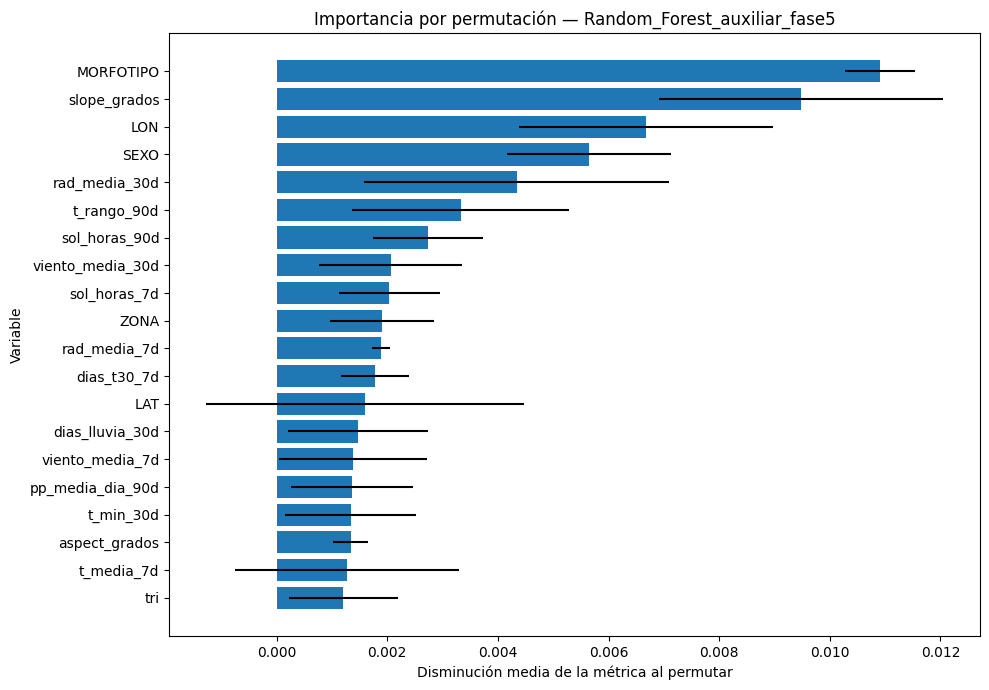


Generando Partial Dependence Plots para variables numéricas principales...


Generando PDP:   0%|          | 0/4 [00:00<?, ?var/s]

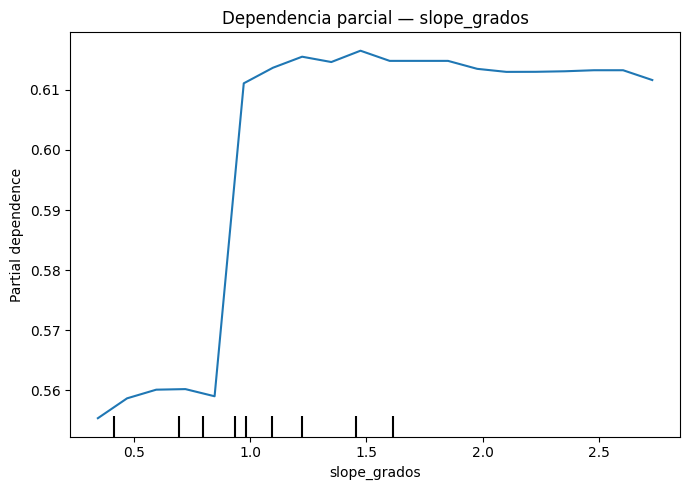

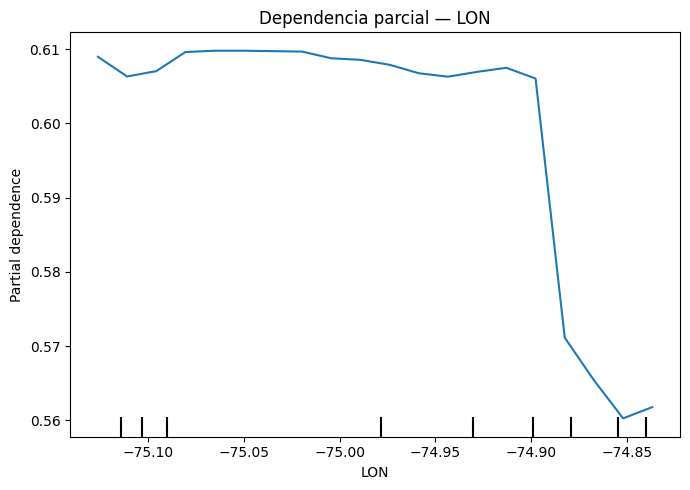

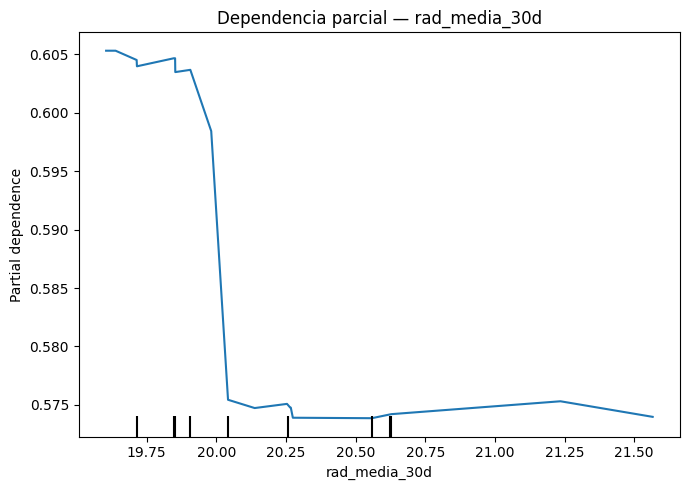

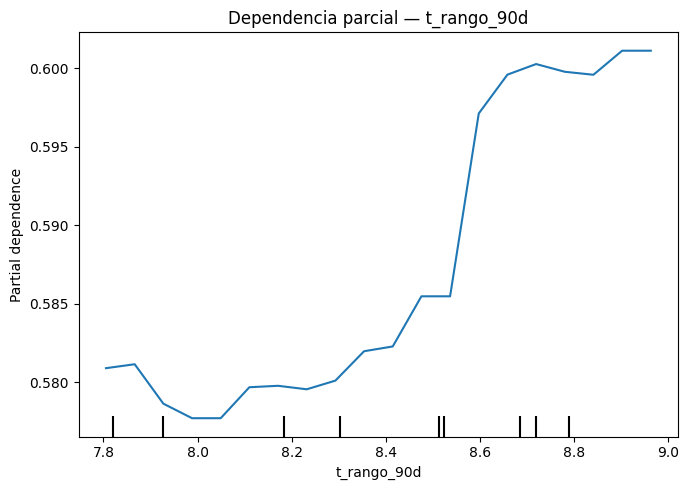

,variable,archivo,estado
0,slope_grados,resultados_fase5/pdp_slope_grados.png,generado
1,LON,resultados_fase5/pdp_LON.png,generado
2,rad_media_30d,resultados_fase5/pdp_rad_media_30d.png,generado
3,t_rango_90d,resultados_fase5/pdp_t_rango_90d.png,generado



Intentando calcular SHAP en muestra reducida...


SHAP:   0%|          | 0/3 [00:00<?, ?paso/s]

<Figure size 640x480 with 0 Axes>

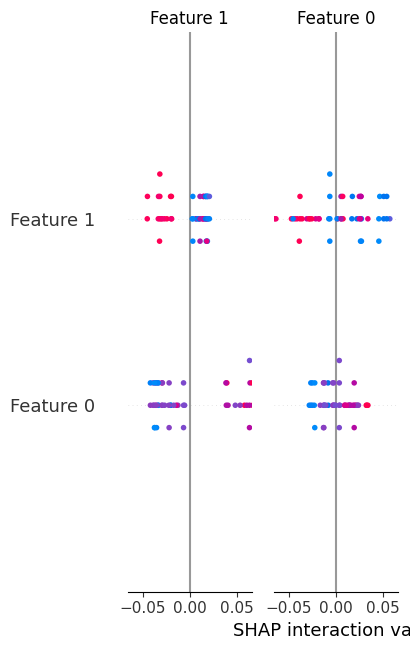

SHAP generado en: resultados_fase5/shap_summary_fitoplasma.png

Revisando si el modelo permite odds-ratios...
El modelo final no es logístico; no se calcularon odds-ratios.

Análisis descriptivo de Espiroplasma...
Columna usada para Espiroplasma: ESPIROPLASMA


,valor,n
0,0,185
1,1,3


Positivos Espiroplasma: 3
Negativos Espiroplasma: 185


Tablas categóricas Espiroplasma:   0%|          | 0/6 [00:00<?, ?var/s]


Tabla Espiroplasma x DEPARTAMENTO


...

espiroplasma_binario,variable,SEXO,0,1,All
0,SEXO,Hembra,137,1,138
1,SEXO,Macho,48,2,50
2,SEXO,All,185,3,188



Tabla Espiroplasma x MORFOTIPO


espiroplasma_binario,variable,MORFOTIPO,0,1,All
0,MORFOTIPO,Morfotipo I,103,1,104
1,MORFOTIPO,Morfotipo II,60,2,62
2,MORFOTIPO,Morfotipo IV,22,0,22
3,MORFOTIPO,All,185,3,188


Resumen numérico Espiroplasma:   0%|          | 0/114 [00:00<?, ?var/s]

,variable,media_positivos,mediana_positivos,media_negativos,mediana_negativos,diferencia_medias_pos_menos_neg,n_positivos_validos,n_negativos_validos
53,deficit_hidrico_90d,-63.686667,-68.150000,-124.764108,-158.040000,61.077441,3,185
47,pp_total_90d,462.333333,454.700000,518.644865,546.000000,-56.311532,3,185
72,deficit_hidrico_120d,-180.386667,-230.970000,-226.223622,-194.670000,45.836955,3,185
66,pp_total_120d,706.333333,740.300000,743.449730,717.200000,-37.116396,3,185
2,ALTITUD_M,326.333333,324.000000,357.713514,324.000000,-31.380180,3,185
34,deficit_hidrico_30d,59.966667,55.480000,35.152216,48.030000,24.814450,3,185
28,pp_total_30d,72.966667,74.500000,94.345405,75.700000,-21.378739,3,185
79,sol_horas_120d,1234.770971,1220.895967,1216.649979,1207.802528,18.120993,3,185
74,gdd_120d,1933.733333,1920.300000,1917.951351,1926.500000,15.781982,3,185
60,sol_horas_90d,947.601151,942.561583,932.532157,928.566847,15.068994,3,185


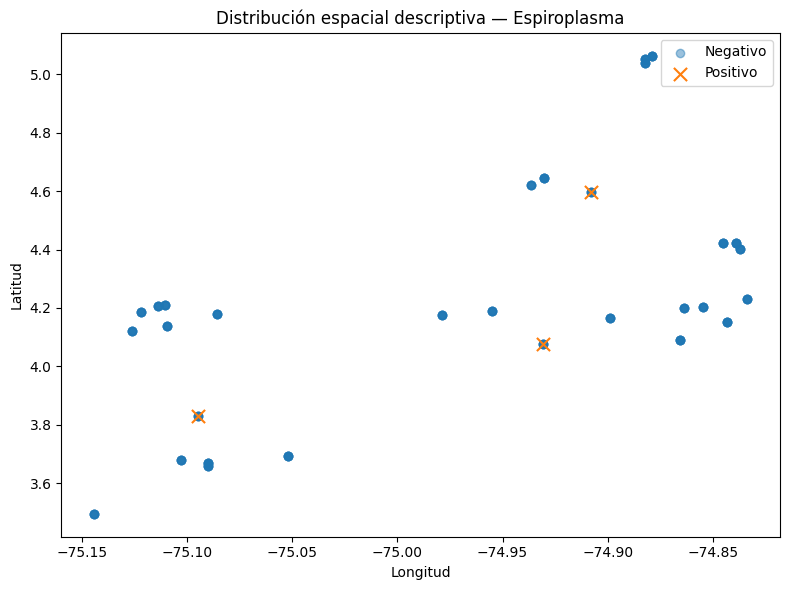


Advertencia metodológica para Espiroplasma:
Espiroplasma presentó una frecuencia positiva extremadamente baja. En la base analizada se identificaron 3 positivos frente a 185 negativos. Por esta razón, no se ajustó un modelo predictivo para este patógeno, debido a que cualquier clasificador tendería a aprender la clase mayoritaria y producir estimaciones inestables. El tratamiento recomendado es descriptivo y exploratorio, centrado en identificar las características comunes de los casos positivos.

FASE 5 FINALIZADA
- resultados_fase5/advertencia_metodologica_espiroplasma.txt
- resultados_fase5/espiroplasma_positivos.csv
- resultados_fase5/importancia_permutacion_fitoplasma.csv
- resultados_fase5/importancia_permutacion_fitoplasma.png
- resultados_fase5/mapa_descriptivo_espiroplasma.png
- resultados_fase5/pdp_LON.png
- resultados_fase5/pdp_rad_media_30d.png
- resultados_fase5/pdp_slope_grados.png
- resultados_fase5/pdp_t_rango_90d.png
- resultados_fase5/predicciones_fitoplasma_modelo_f

In [16]:
# ============================================================
# FASE 5 — Interpretabilidad y descripción de Espiroplasma
# Celda corregida: no falla si no existen best_model_name,
# best_model o preprocessor. Los reconstruye cuando es posible.
# ============================================================

import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from tqdm.auto import tqdm

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import roc_auc_score, average_precision_score

warnings.filterwarnings("ignore")

print("=" * 80)
print("FASE 5 — Interpretabilidad y descripción de Espiroplasma")
print("=" * 80)

os.makedirs("resultados_fase5", exist_ok=True)

# ------------------------------------------------------------
# 0. Funciones auxiliares
# ------------------------------------------------------------

def normalizar_nombre_columna(x):
    return (
        str(x)
        .strip()
        .lower()
        .replace("á", "a")
        .replace("é", "e")
        .replace("í", "i")
        .replace("ó", "o")
        .replace("ú", "u")
        .replace("ñ", "n")
        .replace("\n", " ")
        .replace("-", " ")
        .replace("_", " ")
    )


def buscar_columna(df, posibles_nombres):
    nombres_objetivo = [normalizar_nombre_columna(x) for x in posibles_nombres]

    for col in df.columns:
        col_norm = normalizar_nombre_columna(col)

        for nombre in nombres_objetivo:
            if nombre == col_norm or nombre in col_norm:
                return col

    return None


def convertir_binaria(serie):
    if serie.dtype == "O" or str(serie.dtype).startswith("category"):
        s = (
            serie.astype(str)
            .str.strip()
            .str.lower()
            .str.replace("á", "a", regex=False)
            .str.replace("é", "e", regex=False)
            .str.replace("í", "i", regex=False)
            .str.replace("ó", "o", regex=False)
            .str.replace("ú", "u", regex=False)
        )

        mapa = {
            "positivo": 1,
            "positiva": 1,
            "pos": 1,
            "si": 1,
            "sí": 1,
            "s": 1,
            "1": 1,
            "true": 1,
            "verdadero": 1,
            "negativo": 0,
            "negativa": 0,
            "neg": 0,
            "no": 0,
            "n": 0,
            "0": 0,
            "false": 0,
            "falso": 0,
        }

        return pd.to_numeric(s.replace(mapa), errors="coerce")

    return pd.to_numeric(serie, errors="coerce")


def predecir_probabilidad(modelo, X_data):
    if hasattr(modelo, "predict_proba"):
        return modelo.predict_proba(X_data)[:, 1]

    if hasattr(modelo, "decision_function"):
        raw = modelo.decision_function(X_data)
        raw = np.asarray(raw)

        if raw.max() == raw.min():
            return np.full(len(raw), 0.5)

        return (raw - raw.min()) / (raw.max() - raw.min())

    pred = modelo.predict(X_data)
    return np.asarray(pred, dtype=float)


def limpiar_nombre_archivo(x):
    x = str(x)
    x = re.sub(r"[^\w\-_\. ]", "_", x)
    x = x.replace(" ", "_")
    return x[:80]


# ------------------------------------------------------------
# 1. Recuperar df_model, X, y y groups
# ------------------------------------------------------------

if "df_model" not in globals():
    if "df_master" in globals():
        df_model = df_master.copy()
        print("Se usó df_master como df_model.")
    elif "df" in globals():
        df_model = df.copy()
        print("Se usó df como df_model.")
    elif os.path.exists("fase3_base_maestra.csv"):
        df_model = pd.read_csv("fase3_base_maestra.csv")
        print("Se cargó fase3_base_maestra.csv como df_model.")
    elif os.path.exists("resultados_fase3/fase3_base_maestra.csv"):
        df_model = pd.read_csv("resultados_fase3/fase3_base_maestra.csv")
        print("Se cargó resultados_fase3/fase3_base_maestra.csv como df_model.")
    else:
        raise ValueError(
            "No se encontró df_model, df_master, df ni fase3_base_maestra.csv. "
            "Ejecuta primero las fases previas o carga la base maestra."
        )

col_fit = buscar_columna(
    df_model,
    [
        "fitoplasma",
        "deteccion fitoplasma",
        "detección fitoplasma",
        "deteccion_fitoplasma",
        "detección_fitoplasma",
        "phytoplasma",
    ],
)

if col_fit is None and "y" not in globals():
    raise ValueError(
        "No se encontró la columna de Fitoplasma y tampoco existe y en memoria."
    )

if "y" not in globals():
    y = convertir_binaria(df_model[col_fit])
    mask_y = y.notna()
    df_model = df_model.loc[mask_y].copy()
    y = y.loc[mask_y].astype(int).reset_index(drop=True)
    df_model = df_model.reset_index(drop=True)
    print(f"Target Fitoplasma detectado automáticamente: {col_fit}")
else:
    y = pd.Series(y).reset_index(drop=True)

if "groups" not in globals():
    posibles_grupo = [
        "grupo_colecta",
        "punto_colecta",
        "grupo",
        "site_id",
        "sitio",
    ]

    col_grupo = buscar_columna(df_model, posibles_grupo)

    if col_grupo is not None:
        groups = df_model[col_grupo].astype(str).reset_index(drop=True)
        print(f"Grupo de colecta detectado automáticamente: {col_grupo}")
    else:
        col_mun = buscar_columna(df_model, ["municipio"])
        col_ver = buscar_columna(df_model, ["vereda"])
        col_fecha = buscar_columna(df_model, ["fecha de colecta", "fecha_colecta", "fecha"])
        col_lat = buscar_columna(df_model, ["latitud", "latitude", "lat"])
        col_lon = buscar_columna(df_model, ["longitud", "longitude", "lon", "lng"])

        piezas = []

        for c in [col_mun, col_ver, col_fecha, col_lat, col_lon]:
            if c is not None:
                piezas.append(df_model[c].astype(str))

        if len(piezas) > 0:
            groups = piezas[0]

            for p in piezas[1:]:
                groups = groups + "_" + p

            groups = groups.reset_index(drop=True)
            print("Grupo de colecta construido automáticamente desde municipio/vereda/fecha/coordenadas.")
        else:
            groups = pd.Series(np.arange(len(df_model))).astype(str)
            print("No se detectó grupo de colecta; se usó un grupo por fila.")

else:
    groups = pd.Series(groups).reset_index(drop=True)

if "X" not in globals():
    columnas_excluir = set()

    for c in df_model.columns:
        c_norm = normalizar_nombre_columna(c)

        if "fitoplasma" in c_norm:
            columnas_excluir.add(c)

        if "espiroplasma" in c_norm or "spiroplasma" in c_norm:
            columnas_excluir.add(c)

        if c_norm in ["grupo colecta", "punto colecta", "grupo"]:
            columnas_excluir.add(c)

    columnas_excluir = list(columnas_excluir)

    X = df_model.drop(columns=columnas_excluir, errors="ignore").copy()

    for c in X.columns:
        if X[c].dtype == "O":
            X[c] = X[c].astype(str).replace({"nan": np.nan, "None": np.nan})

    print("X fue construido automáticamente desde df_model.")
else:
    X = X.copy().reset_index(drop=True)

X = X.reset_index(drop=True)

print(f"\nIndividuos : {len(df_model)}")
print(f"Predictores: {X.shape[1]}")
print(f"Positivos Fitoplasma: {int(np.sum(y == 1))}")
print(f"Negativos Fitoplasma: {int(np.sum(y == 0))}")

# ------------------------------------------------------------
# 2. Recuperar o reconstruir el mejor modelo
# ------------------------------------------------------------

modelo_recuperado = False

if "best_model" in globals() and best_model is not None:
    modelo_final = best_model
    nombre_modelo_final = globals().get("best_model_name", "Modelo_recuperado")
    modelo_recuperado = True
    print(f"\nModelo recuperado desde memoria: {nombre_modelo_final}")

elif "resultados_modelos" in globals():
    try:
        tabla_tmp = resultados_modelos.copy()

        if isinstance(tabla_tmp, pd.DataFrame):
            posibles_metricas = [
                "roc_auc_media",
                "roc_auc",
                "pr_auc_media",
                "balanced_accuracy_media",
                "f1_media",
            ]

            metrica_orden = None

            for m in posibles_metricas:
                if m in tabla_tmp.columns:
                    metrica_orden = m
                    break

            if metrica_orden is not None:
                fila_best = tabla_tmp.sort_values(metrica_orden, ascending=False).iloc[0]
                posible_nombre = None

                for c in ["modelo", "model", "nombre_modelo", "model_name"]:
                    if c in tabla_tmp.columns:
                        posible_nombre = fila_best[c]
                        break

                if posible_nombre is not None:
                    for obj_name, obj_value in globals().items():
                        if str(posible_nombre).lower() in str(obj_name).lower():
                            if hasattr(obj_value, "fit") and hasattr(obj_value, "predict"):
                                modelo_final = obj_value
                                nombre_modelo_final = str(posible_nombre)
                                modelo_recuperado = True
                                break
    except Exception:
        pass

if not modelo_recuperado:
    print("\nNo se encontró best_model en memoria.")
    print("Se entrenará un Random Forest rápido para poder ejecutar la Fase 5.")

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor_auto = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols),
        ],
        remainder="drop",
    )

    modelo_final = Pipeline(
        steps=[
            ("preprocessor", preprocessor_auto),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=5,
                    min_samples_leaf=3,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    with tqdm(total=1, desc="Entrenando modelo auxiliar", unit="modelo") as pbar:
        modelo_final.fit(X, y)
        pbar.update(1)

    nombre_modelo_final = "Random_Forest_auxiliar_fase5"
    best_model = modelo_final
    best_model_name = nombre_modelo_final

print(f"Modelo interpretado: {nombre_modelo_final}")

try:
    preprocessor = modelo_final.named_steps["preprocessor"]
except Exception:
    preprocessor = globals().get("preprocessor", None)

# ------------------------------------------------------------
# 3. Predicciones generales
# ------------------------------------------------------------

print("\nCalculando predicciones del modelo para Fitoplasma...")

with tqdm(total=1, desc="Predicción Fitoplasma", unit="paso") as pbar:
    y_score = predecir_probabilidad(modelo_final, X)
    y_pred = (y_score >= 0.5).astype(int)
    pbar.update(1)

try:
    auc_fit = roc_auc_score(y, y_score)
except Exception:
    auc_fit = np.nan

try:
    pr_auc_fit = average_precision_score(y, y_score)
except Exception:
    pr_auc_fit = np.nan

print(f"ROC-AUC aparente: {auc_fit:.4f}" if not np.isnan(auc_fit) else "ROC-AUC aparente: no calculable")
print(f"PR-AUC aparente : {pr_auc_fit:.4f}" if not np.isnan(pr_auc_fit) else "PR-AUC aparente: no calculable")

predicciones_fase5 = pd.DataFrame({
    "grupo_colecta": groups,
    "fitoplasma_observado": y,
    "fitoplasma_probabilidad": y_score,
    "fitoplasma_predicho": y_pred,
})

predicciones_fase5.to_csv(
    "resultados_fase5/predicciones_fitoplasma_modelo_final.csv",
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 4. Importancia por permutación manual con barra de progreso
# ------------------------------------------------------------

print("\nCalculando importancia por permutación con barra de progreso...")

N_REPEATS = 3
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

try:
    baseline_metric = roc_auc_score(y, y_score)
    metric_name = "roc_auc"
except Exception:
    baseline_metric = average_precision_score(y, y_score)
    metric_name = "pr_auc"

print(f"Métrica usada: {metric_name}")
print(f"Valor base   : {baseline_metric:.4f}")

perm_results = []
total_steps = X.shape[1] * N_REPEATS

with tqdm(total=total_steps, desc="Permutando variables", unit="perm") as pbar:
    for col in X.columns:
        drops = []

        for rep in range(N_REPEATS):
            X_perm = X.copy()
            X_perm[col] = rng.permutation(X_perm[col].values)

            score_perm = predecir_probabilidad(modelo_final, X_perm)

            try:
                metric_perm = roc_auc_score(y, score_perm)
            except Exception:
                metric_perm = average_precision_score(y, score_perm)

            drops.append(baseline_metric - metric_perm)

            pbar.set_postfix({
                "variable": str(col)[:22],
                "rep": rep + 1
            })
            pbar.update(1)

        perm_results.append({
            "variable": col,
            "importancia_media": float(np.mean(drops)),
            "importancia_std": float(np.std(drops)),
            "n_repeticiones": N_REPEATS,
        })

importancia_perm = (
    pd.DataFrame(perm_results)
    .sort_values("importancia_media", ascending=False)
    .reset_index(drop=True)
)

display(importancia_perm.head(20))

importancia_perm.to_csv(
    "resultados_fase5/importancia_permutacion_fitoplasma.csv",
    index=False,
    encoding="utf-8-sig"
)

top_n = min(20, len(importancia_perm))

plt.figure(figsize=(10, max(5, top_n * 0.35)))
plt.barh(
    importancia_perm.head(top_n)["variable"][::-1],
    importancia_perm.head(top_n)["importancia_media"][::-1],
    xerr=importancia_perm.head(top_n)["importancia_std"][::-1],
)
plt.xlabel("Disminución media de la métrica al permutar")
plt.ylabel("Variable")
plt.title(f"Importancia por permutación — {nombre_modelo_final}")
plt.tight_layout()
plt.savefig(
    "resultados_fase5/importancia_permutacion_fitoplasma.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# ------------------------------------------------------------
# 5. Partial Dependence Plots rápidos
# ------------------------------------------------------------

print("\nGenerando Partial Dependence Plots para variables numéricas principales...")

numeric_cols_pdp = X.select_dtypes(include=[np.number]).columns.tolist()

top_numeric_features = [
    v for v in importancia_perm["variable"].tolist()
    if v in numeric_cols_pdp
][:4]

pdp_rows = []

if len(top_numeric_features) == 0:
    print("No se encontraron variables numéricas para PDP.")
else:
    for feature in tqdm(top_numeric_features, desc="Generando PDP", unit="var"):
        try:
            fig, ax = plt.subplots(figsize=(7, 5))

            PartialDependenceDisplay.from_estimator(
                modelo_final,
                X,
                features=[feature],
                ax=ax,
                grid_resolution=20,
            )

            ax.set_title(f"Dependencia parcial — {feature}")
            plt.tight_layout()

            safe_feature = limpiar_nombre_archivo(feature)
            output_path = f"resultados_fase5/pdp_{safe_feature}.png"

            plt.savefig(output_path, dpi=300, bbox_inches="tight")
            plt.show()

            pdp_rows.append({
                "variable": feature,
                "archivo": output_path,
                "estado": "generado",
            })

        except Exception as e:
            pdp_rows.append({
                "variable": feature,
                "archivo": None,
                "estado": f"no_generado: {str(e)}",
            })

    pdp_resumen = pd.DataFrame(pdp_rows)
    display(pdp_resumen)

    pdp_resumen.to_csv(
        "resultados_fase5/resumen_partial_dependence.csv",
        index=False,
        encoding="utf-8-sig",
    )

# ------------------------------------------------------------
# 6. SHAP opcional reducido
# ------------------------------------------------------------

print("\nIntentando calcular SHAP en muestra reducida...")

CALCULAR_SHAP = True
SHAP_SAMPLE_SIZE = min(50, len(X))

if CALCULAR_SHAP:
    try:
        import shap

        X_shap = X.sample(n=SHAP_SAMPLE_SIZE, random_state=42)

        with tqdm(total=3, desc="SHAP", unit="paso") as pbar:
            pbar.set_postfix_str("preparando datos")

            if isinstance(modelo_final, Pipeline):
                modelo_interno = modelo_final.named_steps.get("model", modelo_final)
                prep_interno = modelo_final.named_steps.get("preprocessor", None)

                if prep_interno is not None:
                    X_shap_trans = prep_interno.transform(X_shap)
                else:
                    X_shap_trans = X_shap
            else:
                modelo_interno = modelo_final
                X_shap_trans = X_shap

            pbar.update(1)

            pbar.set_postfix_str("creando explicador")

            try:
                explainer = shap.Explainer(modelo_interno, X_shap_trans)
                pbar.update(1)

                pbar.set_postfix_str("calculando valores")
                shap_values = explainer(X_shap_trans)
                pbar.update(1)

                plt.figure()
                shap.summary_plot(shap_values, show=False)
                plt.tight_layout()
                plt.savefig(
                    "resultados_fase5/shap_summary_fitoplasma.png",
                    dpi=300,
                    bbox_inches="tight",
                )
                plt.show()

            except Exception:
                pbar.update(1)

                pbar.set_postfix_str("usando predict_proba")
                explainer = shap.Explainer(modelo_final.predict_proba, X_shap)
                shap_values = explainer(X_shap)
                pbar.update(1)

                plt.figure()
                shap.summary_plot(shap_values, X_shap, show=False)
                plt.tight_layout()
                plt.savefig(
                    "resultados_fase5/shap_summary_fitoplasma.png",
                    dpi=300,
                    bbox_inches="tight",
                )
                plt.show()

        print("SHAP generado en: resultados_fase5/shap_summary_fitoplasma.png")

    except Exception as e:
        print("SHAP no se pudo calcular en este entorno.")
        print(f"Motivo: {e}")

# ------------------------------------------------------------
# 7. Odds-ratios si el modelo interno es logístico
# ------------------------------------------------------------

print("\nRevisando si el modelo permite odds-ratios...")

try:
    if isinstance(modelo_final, Pipeline):
        modelo_interno = modelo_final.named_steps.get("model", None)
        prep_interno = modelo_final.named_steps.get("preprocessor", None)
    else:
        modelo_interno = modelo_final
        prep_interno = preprocessor

    if modelo_interno is not None and hasattr(modelo_interno, "coef_"):
        if prep_interno is not None and hasattr(prep_interno, "get_feature_names_out"):
            feature_names = prep_interno.get_feature_names_out()
        else:
            feature_names = X.columns

        coefs = modelo_interno.coef_.ravel()

        odds_ratios = pd.DataFrame({
            "variable_transformada": feature_names[:len(coefs)],
            "coeficiente": coefs,
            "odds_ratio": np.exp(coefs),
        }).sort_values("odds_ratio", ascending=False)

        display(odds_ratios.head(30))

        odds_ratios.to_csv(
            "resultados_fase5/odds_ratios_fitoplasma.csv",
            index=False,
            encoding="utf-8-sig",
        )

        print("Odds-ratios exportados.")
    else:
        print("El modelo final no es logístico; no se calcularon odds-ratios.")

except Exception as e:
    print("No fue posible calcular odds-ratios.")
    print(f"Motivo: {e}")

# ------------------------------------------------------------
# 8. Análisis descriptivo de Espiroplasma
# ------------------------------------------------------------

print("\nAnálisis descriptivo de Espiroplasma...")

col_esp = buscar_columna(
    df_model,
    [
        "espiroplasma",
        "deteccion espiroplasma",
        "detección espiroplasma",
        "deteccion_espiroplasma",
        "detección_espiroplasma",
        "spiroplasma",
    ],
)

if col_esp is None:
    print("No se encontró una columna clara de Espiroplasma en df_model.")
else:
    print(f"Columna usada para Espiroplasma: {col_esp}")

    df_esp = df_model.copy()
    df_esp["espiroplasma_binario"] = convertir_binaria(df_esp[col_esp])

    conteo_esp = (
        df_esp["espiroplasma_binario"]
        .value_counts(dropna=False)
        .rename_axis("valor")
        .reset_index(name="n")
    )

    display(conteo_esp)

    positivos_esp = df_esp[df_esp["espiroplasma_binario"] == 1].copy()
    negativos_esp = df_esp[df_esp["espiroplasma_binario"] == 0].copy()

    print(f"Positivos Espiroplasma: {len(positivos_esp)}")
    print(f"Negativos Espiroplasma: {len(negativos_esp)}")

    positivos_esp.to_csv(
        "resultados_fase5/espiroplasma_positivos.csv",
        index=False,
        encoding="utf-8-sig",
    )

    posibles_cat = [
        "departamento",
        "zona",
        "municipio",
        "vereda",
        "sexo",
        "morfotipo",
    ]

    cat_cols_esp = []

    for nombre in posibles_cat:
        c = buscar_columna(df_esp, [nombre])
        if c is not None and c not in cat_cols_esp:
            cat_cols_esp.append(c)

    tablas_cat = []

    for col in tqdm(cat_cols_esp, desc="Tablas categóricas Espiroplasma", unit="var"):
        tabla = pd.crosstab(
            df_esp[col],
            df_esp["espiroplasma_binario"],
            margins=True,
        ).reset_index()

        tabla.insert(0, "variable", col)
        tablas_cat.append(tabla)

        print(f"\nTabla Espiroplasma x {col}")
        display(tabla)

    if tablas_cat:
        tablas_cat_export = pd.concat(tablas_cat, ignore_index=True)
        tablas_cat_export.to_csv(
            "resultados_fase5/tablas_categoricas_espiroplasma.csv",
            index=False,
            encoding="utf-8-sig",
        )

    num_cols_esp = df_esp.select_dtypes(include=[np.number]).columns.tolist()
    num_cols_esp = [
        c for c in num_cols_esp
        if c != "espiroplasma_binario"
        and "fitoplasma" not in normalizar_nombre_columna(c)
        and "espiroplasma" not in normalizar_nombre_columna(c)
    ]

    resumen_num = []

    for col in tqdm(num_cols_esp, desc="Resumen numérico Espiroplasma", unit="var"):
        pos_vals = positivos_esp[col].dropna() if col in positivos_esp.columns else pd.Series(dtype=float)
        neg_vals = negativos_esp[col].dropna() if col in negativos_esp.columns else pd.Series(dtype=float)

        if len(pos_vals) > 0 and len(neg_vals) > 0:
            resumen_num.append({
                "variable": col,
                "media_positivos": pos_vals.mean(),
                "mediana_positivos": pos_vals.median(),
                "media_negativos": neg_vals.mean(),
                "mediana_negativos": neg_vals.median(),
                "diferencia_medias_pos_menos_neg": pos_vals.mean() - neg_vals.mean(),
                "n_positivos_validos": len(pos_vals),
                "n_negativos_validos": len(neg_vals),
            })

    resumen_num_esp = pd.DataFrame(resumen_num)

    if not resumen_num_esp.empty:
        resumen_num_esp = resumen_num_esp.sort_values(
            "diferencia_medias_pos_menos_neg",
            key=lambda s: s.abs(),
            ascending=False,
        )

        display(resumen_num_esp.head(30))

        resumen_num_esp.to_csv(
            "resultados_fase5/resumen_numerico_espiroplasma.csv",
            index=False,
            encoding="utf-8-sig",
        )

    lat_col = buscar_columna(df_esp, ["latitud", "latitude", "lat"])
    lon_col = buscar_columna(df_esp, ["longitud", "longitude", "lon", "lng"])

    if lat_col is not None and lon_col is not None:
        plt.figure(figsize=(8, 6))

        plt.scatter(
            negativos_esp[lon_col],
            negativos_esp[lat_col],
            alpha=0.45,
            label="Negativo",
        )

        plt.scatter(
            positivos_esp[lon_col],
            positivos_esp[lat_col],
            s=90,
            marker="x",
            label="Positivo",
        )

        plt.xlabel("Longitud")
        plt.ylabel("Latitud")
        plt.title("Distribución espacial descriptiva — Espiroplasma")
        plt.legend()
        plt.tight_layout()

        plt.savefig(
            "resultados_fase5/mapa_descriptivo_espiroplasma.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()

    texto_advertencia = (
        "Espiroplasma presentó una frecuencia positiva extremadamente baja. "
        f"En la base analizada se identificaron {len(positivos_esp)} positivos frente a "
        f"{len(negativos_esp)} negativos. Por esta razón, no se ajustó un modelo "
        "predictivo para este patógeno, debido a que cualquier clasificador tendería "
        "a aprender la clase mayoritaria y producir estimaciones inestables. "
        "El tratamiento recomendado es descriptivo y exploratorio, centrado en "
        "identificar las características comunes de los casos positivos."
    )

    with open(
        "resultados_fase5/advertencia_metodologica_espiroplasma.txt",
        "w",
        encoding="utf-8",
    ) as f:
        f.write(texto_advertencia)

    print("\nAdvertencia metodológica para Espiroplasma:")
    print(texto_advertencia)

# ------------------------------------------------------------
# 9. Resumen final
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FASE 5 FINALIZADA")
print("=" * 80)

archivos_generados = sorted(os.listdir("resultados_fase5"))

for archivo in archivos_generados:
    print(f"- resultados_fase5/{archivo}")